# FedProp TMLR — Data & Results Catalog Notebook

**Mirror of:** `experiments/FedProp_Data_Results_Catalog.md`  
**Purpose:** One cell per catalog item — load data, render figures, track what still needs runs.

---

### Quick Navigation
| Section | Items | Status |
|---------|-------|--------|
| [§Datasets](#datasets) | Cora · Citeseer · Pubmed · OGBN-Arxiv · Amazon Comp · Amazon Photos · Texas · Wisconsin | Mix |
| [§Sources — Results Catalog](#sources) | Last-7-days scan · 1-hop vs 2-hop · directory summary | Auto |
| [§Config Registry](#config-registry) | Config README · family/dataset/model/hop tree · active/archive paths | Source |
| [§B — Main Tables](#B) | B1 Main Accuracy · B2 Comm Efficiency · B3 Backbone · B4 Heterophilic | Partial |
| [§C — Figures](#C) | C1 Scatter · C2 Error Decomp · C3 Convergence · C4 Scalability · C5 Homophily · C6 PE | Partial |
| [§D — Data Runs](#D) | D1 Amazon Comp · D2 Amazon Photos · D3 Texas · D4 Wisconsin · D5 FedSage+ · D6 Conv · D7 OGBN · D8 PE · D9 CommCost | Mix |
| [§E — Appendix](#E) | E1 Full Ablation · E2 Conv Stats · E3 Prop Cost · E4 Dataset Stats · E5 FedCog | Partial |

**Status legend:** 🟢 Done (data + figure) &nbsp; 🟡 Partial (data exists, work needed) &nbsp; 🔴 To Run (no data yet)

---
## Setup
<a id='setup'></a>

In [12]:
# ── Core imports ────────────────────────────────────────────────────────────
import os, sys, re, ast, glob, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

print('Imports OK')

Imports OK


In [2]:
# ── Root paths ───────────────────────────────────────────────────────────────
FP_ROOT   = Path('/home/bosho/FP')          # this repo
CONF_DIR  = FP_ROOT / 'conf'
EXPT_DIR  = FP_ROOT / 'experiments'
RESULTS   = EXPT_DIR / 'results'
OUTPUT    = EXPT_DIR / 'output'
PROP_EVAL = EXPT_DIR / 'propagator_eval'
CONFIGS   = EXPT_DIR / 'configs'
CONFIG_README = CONFIGS / 'README.md'
RESULT_REGISTRY = OUTPUT / 'result_registry'

# ── External / other-codebase roots (set to None if not available) ───────────
# Point these at the repo roots of competing methods if you have them checked out
EXT_ROOTS = {
    'FedGCN'  : None,   # e.g. Path('/home/bosho/FedGCN')
    'FedGAT'  : None,   # e.g. Path('/home/bosho/FedGAT')
    'DistGAT' : None,
    'FedSage+': None,
    'DGCN'    : None,
    'BDS-GCN' : None,
}

# ── Ordering / palette constants ─────────────────────────────────────────────
PROP_ORDER   = ['full', 'adjacency', 'diffusion', 'zero_hop']
PROP_LABELS  = {'full':'Full', 'adjacency':'Adj', 'diffusion':'Diff', 'zero_hop':'Zero'}
DATASET_ORDER = ['Cora', 'Citeseer', 'Pubmed', 'ogbn-arxiv',
                 'Amazon-Comp', 'Amazon-Photos', 'Texas', 'Wisconsin']
METHOD_ORDER  = ['Centralized', 'FedProp-Zero', 'FedProp-Full',
                 'FedProp (Diff-PE)', 'FedGCN', 'FedGAT', 'DistGAT', 'FedSage+']
COLORS = sns.color_palette('tab10', 10)
PROP_COLORS = {p: COLORS[i] for i,p in enumerate(PROP_ORDER)}

print('Paths and constants set.')
print(f'FP_ROOT exists: {FP_ROOT.exists()}')

Paths and constants set.
FP_ROOT exists: True


In [3]:
# ── Shared data-loading helpers ───────────────────────────────────────────────

FOLDER_RE = re.compile(
    r'^(?P<dataset>[a-zA-Z0-9\-]+)'
    r'_(?P<propagation>zero_hop|adjacency|diffusion|full)'
    r'_(?P<model>GCN|GAT)'
    r'_beta(?P<beta>[\d.]+)_clients(?P<num_clients>\d+)_hop(?P<hop>\d+)'
    r'_iter(?P<iter>\d+)_t(?P<t>[\d.]+)_alpha(?P<alpha>[\d.]+)(?P<pe>_pe)?$'
)

def parse_folder(name):
    """Parse experiment folder name → metadata dict or None."""
    m = FOLDER_RE.match(name)
    if not m: return None
    d = m.groupdict()
    return dict(dataset=d['dataset'], propagation=d['propagation'],
                model=d['model'], beta=float(d['beta']),
                num_clients=int(d['num_clients']), hop=int(d['hop']),
                use_pe=d['pe'] is not None)

def load_training_csv(csv_path, return_curves=False):
    """Read a per-client training CSV.
    Returns (mean_acc, std_acc) or full DataFrame if return_curves=True.
    """
    df = pd.read_csv(csv_path)
    final_accs = []
    for _, row in df.iterrows():
        try:
            accs = ast.literal_eval(row['training_accuracies'])
            if accs: final_accs.append(accs[-1])
        except Exception:
            pass
    if return_curves: return df
    if not final_accs: return (np.nan, np.nan)
    return (float(np.mean(final_accs)), float(np.std(final_accs)))

def scan_results_dir(root, dataset_filter=None):
    """Walk root recursively; parse all experiment sub-folders → DataFrame."""
    root = Path(root)
    records = []
    for csv in sorted(root.rglob('training_*.csv')):
        meta = parse_folder(csv.parent.name)
        if meta is None: continue
        if dataset_filter and meta['dataset'] not in dataset_filter: continue
        m, s = load_training_csv(csv)
        meta.update(mean_acc=m, std_acc=s,
                    acc_pct=round(m*100,2) if not np.isnan(m) else np.nan,
                    std_pct=round(s*100,2) if not np.isnan(s) else np.nan,
                    csv_path=str(csv))
        records.append(meta)
    return pd.DataFrame(records)

def load_prop_stats(stats_dir):
    """Load propagation_stats/*.json → DataFrame with residuals per iteration."""
    rows = []
    for f in sorted(Path(stats_dir).glob('*.json')):
        with open(f) as fh:
            d = json.load(fh)
        for c in d.get('clients', []):
            res = c.get('residuals', [])
            for it, r in enumerate(res):
                rows.append(dict(
                    exp_id=d.get('experiment_id',''),
                    propagation=d.get('propagation_mode',''),
                    beta=d.get('beta', np.nan),
                    hop=d.get('hop', np.nan),
                    client_id=c.get('client_id', -1),
                    iteration=it+1, residual=r
                ))
    return pd.DataFrame(rows)

def status_badge(status):
    icons = {'Done':'🟢','Partial':'🟡','To Run':'🔴','Extend':'🟡','Restructure':'🟢','New':'🔴'}
    return icons.get(status, '⚪') + f' **{status}**'

print('Helpers loaded.')

Helpers loaded.


In [4]:
# ── Load the two canonical consolidated tables (used throughout) ──────────────
r1  = pd.read_csv(OUTPUT / 'R1_consolidated.csv')
r1b = pd.read_csv(OUTPUT / 'R1b_consolidated.csv')

for df in (r1, r1b):
    df['beta']    = df['beta'].astype(int)
    df['use_pe']  = df['use_pe'].astype(bool)
    df['acc_pct'] = (df['mean_acc'] * 100).round(2)
    df['std_pct'] = (df['std_acc']  * 100).round(2)

print(f'R1  (GCN): {len(r1)} rows   |   R1b (GAT): {len(r1b)} rows')

# Quick sanity check
print('\nDatasets in R1 :', sorted(r1['dataset'].unique()))
print('Propagations   :', sorted(r1['propagation'].unique()))

R1  (GCN): 33 rows   |   R1b (GAT): 54 rows

Datasets in R1 : ['Citeseer', 'Cora', 'Pubmed']
Propagations   : ['adjacency', 'diffusion', 'full', 'zero_hop']


---
# Config Registry Control Room
<a id='config-registry'></a>

The experiment config registry now lives under:

- Config root: `/home/bosho/FP/experiments/configs/`
- Registry README: `/home/bosho/FP/experiments/configs/README.md`
- Result registry: `/home/bosho/FP/experiments/output/result_registry/`

Use the config tree as the source of truth for new run definitions. The result registry remains the source of truth for consolidated outputs, inventories, archived result tables, and provenance.

```text
experiments/configs/
├── shared/                  # Shared defaults and seed schedules.
├── planetoid/               # Cora, Citeseer, Pubmed.
├── large/                   # ogbn-arxiv, Amazon Computers, Amazon Photos.
├── heterophilic/            # Texas, Wisconsin, Actor, Roman-empire, etc.
├── ablations/               # Cross-dataset sweeps and diagnostic studies.
├── reruns/                  # Top-ups and failed-row reruns.
├── smoke/                   # Fast sanity checks.
└── archive/                 # Historical configs kept for provenance.
```

Canonical config path pattern:

```text
experiments/configs/<family>/<dataset>/<backbone>/<hop>/<purpose>.yaml
```

Examples:

```text
experiments/configs/planetoid/cora/gcn/hop1/main.yaml
experiments/configs/planetoid/cora/gat/hop2/pe.yaml
experiments/configs/large/amazon-computers/gcn/hop2/main.yaml
experiments/configs/heterophilic/roman-empire/gcn/hop1/main.yaml
```

Purpose filenames:

- `main.yaml`: canonical table run for that dataset/backbone/hop.
- `pe.yaml`: positional-encoding variant.
- `topups.yaml`: seed completion for incomplete rows.
- `quickval.yaml`: short validation run.
- `preflight.yaml`: cheap config/runtime validation.
- `client_sweep.yaml`: client-count scalability sweep.

Migration shorthand:

- `R1` → `planetoid/*/gcn/hop1/` and `large/ogbn-arxiv/gcn/hop1/`
- `R1b` → `planetoid/*/gat/hop2/`
- `R5` → `ablations/client_count/`
- `R6` → `heterophilic/texas|wisconsin/gcn/hop1/`
- `R7` → `large/amazon-computers|amazon-photos/gcn/`
- Historical one-offs → `archive/`


---
# Sources — Results Directory Catalog
<a id='sources'></a>

Auto-scan of every `training_*.csv` found under `experiments/` in the **last 7 days**.  
Columns: `path` (relative to `experiments/`) · `date` · `dataset` · `model` · `propagation` · `β` · `hop` · `PE` · `reps` · `mean_acc ± std`  

> **Tip:** run the *Sources — Rescan* cell any time to refresh after new runs complete.

In [5]:
# ── Sources: scan all_results/ symlink farm ──────────────────────────────────
# SCAN_DIR is the unified symlink farm; each subdirectory is a named batch.
# Set SCAN_CUTOFF_DAYS=0 to include all-time results, or e.g. 7 for last week.
import re, ast, json as _json
from datetime import datetime, timedelta
import numpy as np, pandas as pd
from pathlib import Path

SCAN_DIR       = Path('/home/bosho/FP/experiments/all_results')
SCAN_CUTOFF_DAYS = 0      # 0 = no date filter (all-time); 7 = last week only

_FOLDER_RE = re.compile(
    r'^(?P<dataset>[a-zA-Z0-9\-]+)'
    r'_(?P<propagation>zero_hop|adjacency|diffusion|full)'
    r'_(?P<model>GCN|GAT)'
    r'_beta(?P<beta>[\d.]+)_clients(?P<num_clients>\d+)_hop(?P<hop>\d+)'
    r'_iter(?P<iter>\d+)_t(?P<t>[\d.]+)_alpha(?P<alpha>[\d.]+)(?P<pe>_pe)?$'
)
_TS_RE = re.compile(r'(\d{8}_\d{6})')

def _final_acc(csv_path):
    try:
        df = pd.read_csv(csv_path)
        accs = []
        for _, row in df.iterrows():
            try:
                vals = ast.literal_eval(str(row.get('training_accuracies','[]')))
                if vals: accs.append(float(vals[-1]))
            except Exception:
                pass
        if accs:
            return round(np.mean(accs)*100, 2), round(np.std(accs)*100, 2)
    except Exception:
        pass
    return np.nan, np.nan

cutoff = (datetime.now() - timedelta(days=SCAN_CUTOFF_DAYS)
          if SCAN_CUTOFF_DAYS > 0 else datetime(2000, 1, 1))

records = []
for batch_link in sorted(SCAN_DIR.iterdir()):
    if not batch_link.is_dir():          # skip broken or non-dir entries
        continue
    batch = batch_link.name              # e.g. "R1_Cora_GCN_1hop_nope"
    for csv in sorted(batch_link.rglob('training_*.csv')):
        m_ts = _TS_RE.search(csv.name)
        if not m_ts:
            continue
        ts = datetime.strptime(m_ts.group(1), '%Y%m%d_%H%M%S')
        if ts < cutoff:
            continue
        m = _FOLDER_RE.match(csv.parent.name)
        if not m:
            continue
        g = m.groupdict()
        mean_acc, std_acc = _final_acc(csv)
        sibling_reps = len(list(csv.parent.glob('training_*.csv')))
        # True path via symlink resolution
        real_path = str(csv.parent.resolve().relative_to(
            Path('/home/bosho/FP/experiments').resolve()))
        records.append({
            'batch'       : batch,
            'date'        : ts.strftime('%Y-%m-%d'),
            'dataset'     : g['dataset'],
            'model'       : g['model'],
            'propagation' : g['propagation'],
            'beta'        : int(float(g['beta'])),
            'hop'         : int(g['hop']),
            'PE'          : g['pe'] is not None,
            'clients'     : int(g['num_clients']),
            'reps'        : sibling_reps,
            'mean_acc'    : mean_acc,
            'std_acc'     : std_acc,
            'path'        : real_path,
        })

_raw = pd.DataFrame(records)
if _raw.empty:
    SOURCES = pd.DataFrame()
    print('No runs found.')
else:
    SOURCES = (
        _raw.sort_values('date')
            .groupby(['batch','dataset','model','propagation',
                      'beta','hop','PE','clients', 'path'], sort=False)
            .agg(date  =('date',     'last'),
                 reps  =('reps',     'max'),
                 mean_acc=('mean_acc','mean'),
                 std_acc =('std_acc', 'mean'))
            .reset_index()
            .sort_values(['dataset','hop','batch','model','propagation','beta','PE'])
            .reset_index(drop=True)
    )
    SOURCES['mean_acc'] = SOURCES['mean_acc'].round(2)
    SOURCES['std_acc']  = SOURCES['std_acc'].round(2)
    SOURCES['result']   = SOURCES.apply(
        lambda r: f"{r['mean_acc']:.1f} \u00b1 {r['std_acc']:.1f}"
                  if not pd.isna(r['mean_acc']) else '\u2014', axis=1)

    filter_note = f'last {SCAN_CUTOFF_DAYS} days' if SCAN_CUTOFF_DAYS > 0 else 'all-time'
    print(f'Scanned {SCAN_DIR.name}/  ({filter_note})  \u2192  {len(SOURCES)} unique run configs')
    print(f'  Batches  : {len(SOURCES["batch"].unique())}  ({list(SOURCES["batch"].unique())[:6]}...)')
    print(f'  Datasets : {sorted(SOURCES["dataset"].unique())}')
    print(f'  Hop vals : {sorted(SOURCES["hop"].unique())}')
    print(f'  Rep range: {SOURCES["reps"].min()} – {SOURCES["reps"].max()}')


Scanned all_results/  (all-time)  →  315 unique run configs
  Batches  : 30  (['R1_Citeseer_GCN_1hop_nope', 'R1_Citeseer_GCN_1hop_pe', 'R1_Citeseer_GCN_rerun', 'R1_Citeseer_GCN_topup', 'R1b_Citeseer_GAT_2hop_nope', 'R1b_Citeseer_GAT_2hop_pe']...)
  Datasets : ['Citeseer', 'Cora', 'Pubmed', 'ogbn-arxiv']
  Hop vals : [np.int64(1), np.int64(2)]
  Rep range: 1 – 10


In [6]:
# ── Sources: full catalog table — path last, ≥3 reps highlighted ─────────────
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_colwidth', 90)

SOURCES_3    = SOURCES[SOURCES['reps'] >= 3].reset_index(drop=True)
SOURCES_lt3  = SOURCES[SOURCES['reps'] <  3]

_cols = ['date','batch','dataset','model','propagation',
         'beta','hop','PE','clients','reps','result','path']

def _hop_style(col):
    return ['background-color: #dff0d8' if v == 1 else
            'background-color: #d9edf7' if v == 2 else ''
            for v in col]

print(f'Total configs  : {len(SOURCES)}')
print(f'  ≥3 reps      : {len(SOURCES_3)}   (shown in full table below)')
print(f'  <3 reps      : {len(SOURCES_lt3)}  (single-rep / smoke — use SOURCES_lt3 to inspect)')
print()

if not SOURCES_3.empty:
    display(SOURCES_3[_cols].style
        .apply(_hop_style, subset=['hop'])
        .set_caption('≥3 reps  |  🟢 hop=1  🔵 hop=2  |  path is last column'))
else:
    print('No ≥3-rep configs in scan. Showing all:')
    display(SOURCES[_cols].style
        .apply(_hop_style, subset=['hop'])
        .set_caption('All configs  |  🟢 hop=1  🔵 hop=2'))

# ── Also always show the pre-aggregated consolidated tables ──────────────────
print()
print('Pre-aggregated consolidated tables (R1/R1b — from output/):')

_r1_src  = r1.assign(source='R1 (GCN)',
                     path='experiments/output/R1_consolidated.csv')
_r1b_src = r1b.assign(source='R1b (GAT)',
                      path='experiments/output/R1b_consolidated.csv')
_cons = pd.concat([_r1_src, _r1b_src], ignore_index=True)
_cons = _cons[_cons['n_reps'] >= 3].copy()
_cons['result'] = _cons.apply(
    lambda r: f"{r['acc_pct']:.1f} \u00b1 {r['std_pct']:.1f}", axis=1)
_cons_cols = ['source','dataset','model','propagation','beta','hop',
              'use_pe','num_clients','n_reps','result','path']

display(_cons[_cons_cols]
    .rename(columns={'use_pe':'PE','num_clients':'clients','n_reps':'reps'})
    .sort_values(['dataset','source','hop','propagation','beta'])
    .reset_index(drop=True)
    .style
    .apply(_hop_style, subset=['hop'])
    .set_caption('R1/R1b consolidated  |  🟢 hop=1  🔵 hop=2  |  ≥3 reps only'))


Total configs  : 315
  ≥3 reps      : 25   (shown in full table below)
  <3 reps      : 290  (single-rep / smoke — use SOURCES_lt3 to inspect)



,date,batch,dataset,model,propagation,beta,hop,PE,clients,reps,result,path
0,2026-04-29,R1b_Citeseer_GAT_2hop_pe,Citeseer,GAT,adjacency,1,2,True,10,3,99.2 ± 1.9,results/R1b_citeseer_pe/Citeseer_adjacency_GAT_beta1_clients10_hop2_iter50_t0.1_alpha0.5_pe
1,2026-04-29,R1b_Citeseer_GAT_2hop_pe,Citeseer,GAT,adjacency,10,2,True,10,4,99.6 ± 0.7,results/R1b_citeseer_pe/Citeseer_adjacency_GAT_beta10_clients10_hop2_iter50_t0.1_alpha0.5_pe
2,2026-04-29,R1b_Citeseer_GAT_2hop_pe,Citeseer,GAT,adjacency,10000,2,True,10,5,99.6 ± 1.0,results/R1b_citeseer_pe/Citeseer_adjacency_GAT_beta10000_clients10_hop2_iter50_t0.1_alpha0.5_pe
3,2026-04-28,R1_Cora_GCN_1hop_nope,Cora,GCN,adjacency,10000,1,False,10,3,99.6 ± 0.8,results/R1_cora_nope/Cora_adjacency_GCN_beta10000_clients10_hop1_iter50_t0.1_alpha0.5
4,2026-04-28,R1_Cora_GCN_1hop_nope,Cora,GCN,zero_hop,1,1,False,10,3,98.7 ± 2.7,results/R1_cora_nope/Cora_zero_hop_GCN_beta1_clients10_hop1_iter50_t0.1_alpha0.5
5,2026-04-28,R1_Cora_GCN_1hop_nope,Cora,GCN,zero_hop,10,1,False,10,3,95.2 ± 7.8,results/R1_cora_nope/Cora_zero_hop_GCN_beta10_clients10_hop1_iter50_t0.1_alpha0.5
6,2026-04-28,R1_Cora_GCN_1hop_nope,Cora,GCN,zero_hop,10000,1,False,10,6,98.0 ± 4.2,results/R1_cora_nope/Cora_zero_hop_GCN_beta10000_clients10_hop1_iter50_t0.1_alpha0.5
7,2026-04-29,R1b_Cora_GAT_2hop_pe,Cora,GAT,adjacency,1,2,True,10,3,98.8 ± 2.3,results/R1b_cora_pe/Cora_adjacency_GAT_beta1_clients10_hop2_iter50_t0.1_alpha0.5_pe
8,2026-04-29,R1b_Cora_GAT_2hop_pe,Cora,GAT,adjacency,10,2,True,10,5,99.7 ± 0.6,results/R1b_cora_pe/Cora_adjacency_GAT_beta10_clients10_hop2_iter50_t0.1_alpha0.5_pe
9,2026-04-29,R1b_Cora_GAT_2hop_pe,Cora,GAT,adjacency,10000,2,True,10,5,99.6 ± 1.0,results/R1b_cora_pe/Cora_adjacency_GAT_beta10000_clients10_hop2_iter50_t0.1_alpha0.5_pe



Pre-aggregated consolidated tables (R1/R1b — from output/):


,source,dataset,model,propagation,beta,hop,PE,clients,reps,result,path
0,R1 (GCN),Citeseer,GCN,adjacency,1,1,False,10,10,66.3 ± 1.4,experiments/output/R1_consolidated.csv
1,R1 (GCN),Citeseer,GCN,adjacency,10,1,False,10,10,63.4 ± 1.0,experiments/output/R1_consolidated.csv
2,R1 (GCN),Citeseer,GCN,adjacency,10000,1,False,10,10,63.8 ± 1.5,experiments/output/R1_consolidated.csv
3,R1 (GCN),Citeseer,GCN,diffusion,10,1,False,10,10,62.9 ± 1.4,experiments/output/R1_consolidated.csv
4,R1 (GCN),Citeseer,GCN,diffusion,10000,1,False,10,10,62.6 ± 1.5,experiments/output/R1_consolidated.csv
5,R1 (GCN),Citeseer,GCN,full,1,1,False,10,10,69.6 ± 0.8,experiments/output/R1_consolidated.csv
6,R1 (GCN),Citeseer,GCN,full,10,1,False,10,10,69.8 ± 0.8,experiments/output/R1_consolidated.csv
7,R1 (GCN),Citeseer,GCN,full,10000,1,False,10,10,69.7 ± 0.4,experiments/output/R1_consolidated.csv
8,R1 (GCN),Citeseer,GCN,zero_hop,1,1,False,10,3,61.5 ± 1.5,experiments/output/R1_consolidated.csv
9,R1 (GCN),Citeseer,GCN,zero_hop,10,1,False,10,10,58.1 ± 1.8,experiments/output/R1_consolidated.csv


In [7]:
# ── Sources: 1-hop vs 2-hop breakdown ────────────────────────────────────────
if not SOURCES.empty:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    # Summary pivot: dataset × hop → result count
    count_pivot = SOURCES.groupby(['dataset','hop']).size().unstack(fill_value=0)
    count_pivot.columns = [f'hop={c}' for c in count_pivot.columns]
    print('Run counts by dataset × hop:')
    display(count_pivot)

    # Best accuracy per dataset × hop × propagation
    best_pivot = (
        SOURCES[SOURCES['mean_acc'].notna()]
        .groupby(['dataset','hop','propagation'])['mean_acc']
        .max().round(2)
        .unstack('propagation')
        .reset_index()
    )
    print('\nBest mean_acc% per dataset × hop × propagation:')
    display(best_pivot)

Run counts by dataset × hop:


,hop=1,hop=2
dataset,,
Citeseer,24,45
Cora,113,48
Pubmed,24,43
ogbn-arxiv,0,18



Best mean_acc% per dataset × hop × propagation:


propagation,dataset,hop,adjacency,diffusion,full,zero_hop
0,Citeseer,1,99.40,100.00,100.00,98.81
1,Citeseer,2,100.00,100.00,100.00,100.00
2,Cora,1,100.00,100.00,100.00,100.00
3,Cora,2,100.00,100.00,100.00,98.66
4,Pubmed,1,98.81,100.00,98.33,100.00
5,Pubmed,2,100.00,100.00,98.61,91.50
6,ogbn-arxiv,2,86.26,86.31,87.10,79.14


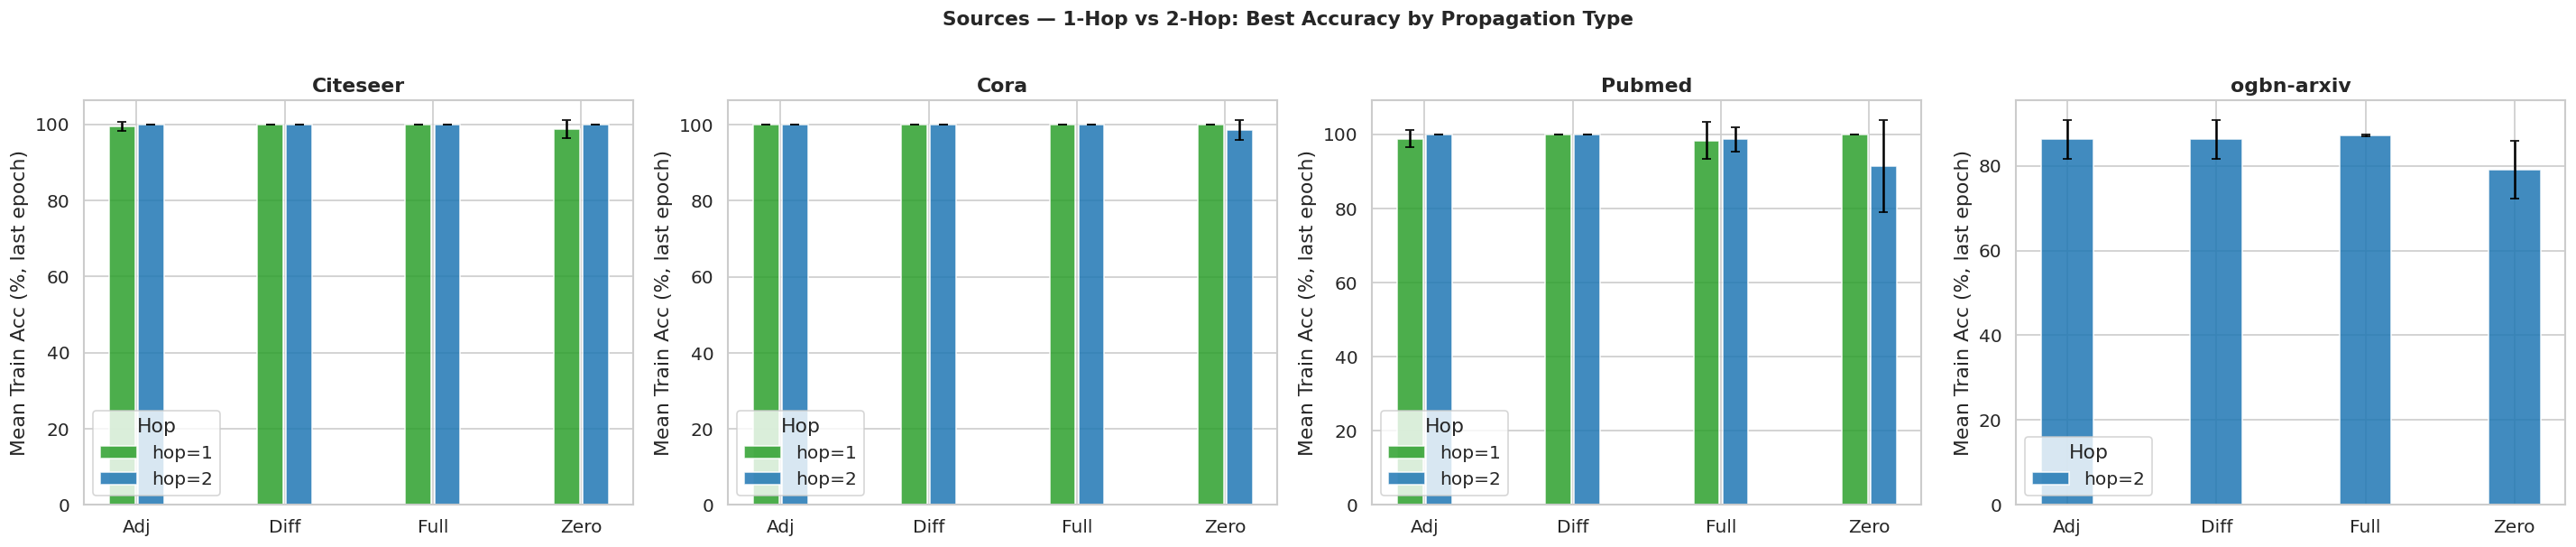

In [8]:
# ── Sources: side-by-side 1-hop vs 2-hop bar chart ───────────────────────────
if not SOURCES.empty and SOURCES['mean_acc'].notna().any():
    import matplotlib.pyplot as plt
    import numpy as np

    _s = SOURCES[SOURCES['mean_acc'].notna()].copy()
    datasets_plot = sorted(_s['dataset'].unique())
    props_plot    = [p for p in ['adjacency','diffusion','full','zero_hop']
                     if p in _s['propagation'].unique()]

    n_ds = len(datasets_plot)
    fig, axes = plt.subplots(1, n_ds, figsize=(6*n_ds, 5), squeeze=False)

    colors_hop = {1: '#2ca02c', 2: '#1f77b4'}   # green=1hop, blue=2hop

    for ax, ds in zip(axes[0], datasets_plot):
        sub = _s[_s['dataset']==ds]
        hops = sorted(sub['hop'].unique())
        x    = np.arange(len(props_plot))
        width = 0.35 / max(len(hops),1)

        for j, hop in enumerate(hops):
            hsub = sub[sub['hop']==hop]
            vals = []
            errs = []
            for prop in props_plot:
                psub = hsub[hsub['propagation']==prop]
                if psub.empty:
                    vals.append(0); errs.append(0)
                else:
                    best_row = psub.loc[psub['mean_acc'].idxmax()]
                    vals.append(best_row['mean_acc'])
                    errs.append(best_row['std_acc'])
            offset = (j - (len(hops)-1)/2) * (width + 0.02)
            ax.bar(x + offset, vals, width,
                   label=f'hop={hop}',
                   color=colors_hop.get(hop, f'C{j}'),
                   alpha=0.85,
                   yerr=errs, capsize=3)

        prop_labels = {'adjacency':'Adj','diffusion':'Diff','full':'Full','zero_hop':'Zero'}
        ax.set_xticks(x)
        ax.set_xticklabels([prop_labels.get(p,p) for p in props_plot])
        ax.set_title(ds, fontweight='bold')
        ax.set_ylabel('Mean Train Acc (%, last epoch)')
        ax.legend(title='Hop')

    plt.suptitle('Sources — 1-Hop vs 2-Hop: Best Accuracy by Propagation Type',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

In [9]:
# ── Sources: path-level directory summary ────────────────────────────────────
# One row per unique parent directory (batch/run group), with date range and coverage
if not SOURCES.empty:
    dir_summary = (
        SOURCES.groupby(
            SOURCES['path'].str.split('/').str[0]  # top-level dir
        ).agg(
            last_date  = ('date',        'max'),
            n_runs     = ('path',        'count'),
            datasets   = ('dataset',     lambda x: ', '.join(sorted(x.unique()))),
            hops       = ('hop',         lambda x: '+'.join(str(h) for h in sorted(x.unique()))),
            models     = ('model',       lambda x: '+'.join(sorted(x.unique()))),
            props      = ('propagation', lambda x: ', '.join(sorted(x.unique()))),
            min_reps   = ('reps',        'min'),
            max_reps   = ('reps',        'max'),
        ).reset_index().rename(columns={'path':'top_dir'})
        .sort_values('last_date', ascending=False)
    )
    dir_summary['reps_range'] = dir_summary.apply(
        lambda r: str(r['min_reps']) if r['min_reps']==r['max_reps']
                  else f"{r['min_reps']}–{r['max_reps']}", axis=1
    )
    print('Directory-level summary (most recent first):')
    display(dir_summary[['top_dir','last_date','n_runs','datasets',
                          'hops','models','props','reps_range']])

Directory-level summary (most recent first):


,top_dir,last_date,n_runs,datasets,hops,models,props,reps_range
0,citeseer_results_prelim,2026-05-08,20,Citeseer,2,GAT+GCN,"adjacency, diffusion, full",1–2
1,cora_results_test,2026-05-08,20,Cora,1+2,GAT+GCN,"adjacency, diffusion",1
2,pubmed_results_prelim,2026-05-08,16,Pubmed,2,GAT+GCN,"adjacency, diffusion",1
3,results,2026-05-07,259,"Citeseer, Cora, Pubmed, ogbn-arxiv",1+2,GAT+GCN,"adjacency, diffusion, full, zero_hop",1–10


---
# Datasets
<a id='datasets'></a>

One section per dataset.  Each section has:
1. **Config paths** — which YAML files control this dataset's runs
2. **Results dirs** — which batches in `all_results/` hold data
3. **Summary table** — all configurations sorted by accuracy, 1-hop vs 2-hop separated
4. **Figures** — propagation × β bar chart; PE-gain chart for GAT runs

Cross-dataset combined tables and figures come later in **§ Combined Analysis**.

In [9]:
# -- Dataset helpers (run once; shared by every dataset section) ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np, pandas as pd

PROP_ORDER   = ['full','adjacency','diffusion','zero_hop']
PROP_LABELS  = {'full':'Full','adjacency':'Adj','diffusion':'Diff','zero_hop':'Zero'}
HOP_COLORS   = {1:'#2ca02c', 2:'#1f77b4'}
PE_HATCH     = {False:'', True:'//'}
BETA_IID     = 10000
BETA_NONIID  = 1

def _ds_data(ds_name, aliases=None):
    """Return (gcn_df, gat_df, raw_df) for a dataset."""
    names = [ds_name] + (aliases or [])
    gcn = r1 [r1 ['dataset'].isin(names)].copy()
    gat = r1b[r1b['dataset'].isin(names)].copy()
    raw = SOURCES[SOURCES['dataset'].isin(names)].copy() if not SOURCES.empty else pd.DataFrame()
    return gcn, gat, raw


def _ds_table(ds_name, gcn, gat, raw):
    """Print a ranked summary table for a dataset."""
    rows = []
    for _, r in gcn.iterrows():
        rows.append({'Source':'R1-cons','Model':'GCN','Hop':int(r['hop']),
                     'Prop':r['propagation'],chr(946):int(r['beta']),'PE':r['use_pe'],
                     'Reps':int(r['n_reps']),
                     'Acc':r['acc_pct'],'Std':r['std_pct']})
    for _, r in gat.iterrows():
        rows.append({'Source':'R1b-cons','Model':'GAT','Hop':int(r['hop']),
                     'Prop':r['propagation'],chr(946):int(r['beta']),'PE':r['use_pe'],
                     'Reps':int(r['n_reps']),
                     'Acc':r['acc_pct'],'Std':r['std_pct']})
    if not raw.empty:
        for _, r in raw.iterrows():
            already = any(
                x['Model']==r['model'] and x['Hop']==r['hop'] and
                x['Prop']==r['propagation'] and x[chr(946)]==r['beta'] and
                x['PE']==r['PE']
                for x in rows
            )
            if already:
                continue
            if not pd.isna(r['mean_acc']):
                rows.append({'Source':r['batch'],'Model':r['model'],'Hop':r['hop'],
                             'Prop':r['propagation'],chr(946):int(r['beta']),'PE':r['PE'],
                             'Reps':r['reps'],
                             'Acc':r['mean_acc'],'Std':r['std_acc']})
    if not rows:
        print(f'No data for {ds_name}')
        return
    df = pd.DataFrame(rows).sort_values('Acc', ascending=False).reset_index(drop=True)
    df['Result'] = df.apply(lambda r: f"{r['Acc']:.1f} ± {r['Std']:.1f}", axis=1)
    df['Prop'] = df['Prop'].map(PROP_LABELS).fillna(df['Prop'])
    beta_col = chr(946)
    display(df[['Source','Model','Hop','Prop',beta_col,'PE','Reps','Result']]
        .style
        .apply(lambda col: ['background-color:#dff0d8' if v==1
                            else 'background-color:#d9edf7' if v==2
                            else '' for v in col], subset=['Hop'])
        .set_caption(f'{ds_name} — all configs ranked by accuracy  |  hop=1 (green)  hop=2 (blue)'))


def _ds_bar(ds_name, gcn, gat, raw, figsize=(14, 5)):
    """Grouped bar chart: propagation x beta, comparing GCN-1hop/GCN-2hop/GAT-2hop/GAT+PE-2hop."""
    rows = []
    for _, r in gcn.iterrows():
        rows.append({'model':'GCN','hop':int(r['hop']),'pe':bool(r['use_pe']),
                     'prop':r['propagation'],'beta':int(r['beta']),
                     'acc':r['acc_pct'],'std':r['std_pct']})
    for _, r in gat.iterrows():
        rows.append({'model':'GAT','hop':int(r['hop']),'pe':bool(r['use_pe']),
                     'prop':r['propagation'],'beta':int(r['beta']),
                     'acc':r['acc_pct'],'std':r['std_pct']})
    if not raw.empty:
        for _, r in raw.iterrows():
            if not pd.isna(r['mean_acc']):
                rows.append({'model':r['model'],'hop':r['hop'],'pe':r['PE'],
                             'prop':r['propagation'],'beta':int(r['beta']),
                             'acc':r['mean_acc'],'std':r['std_acc']})
    if not rows:
        print(f'No data for {ds_name} bar chart')
        return
    df = pd.DataFrame(rows).drop_duplicates(
        subset=['model','hop','pe','prop','beta'], keep='first')

    variants = [
        ('GCN', 1, False, 'GCN-1hop',    '#2ca02c', ''),
        ('GCN', 2, False, 'GCN-2hop',    '#98df8a', ''),
        ('GAT', 2, False, 'GAT-2hop',    '#1f77b4', ''),
        ('GAT', 2, True,  'GAT+PE-2hop', '#aec7e8', '//'),
    ]
    props   = [p for p in PROP_ORDER if p in df['prop'].unique()]
    betas   = sorted([b for b in df['beta'].unique() if b in (1, 10000)])
    n_betas = len(betas)
    beta_lbls = {1:'Non-IID (beta=1)', 10000:'IID (beta=10000)'}
    x       = np.arange(len(props))
    bar_w   = 0.15

    fig, axes = plt.subplots(1, max(n_betas,1), figsize=figsize, sharey=True)
    if n_betas <= 1:
        axes = [axes]

    for ax, beta in zip(axes, betas):
        sub = df[df['beta'] == beta]
        for j, (model, hop, pe, label, color, hatch) in enumerate(variants):
            vsub = sub[(sub['model']==model) & (sub['hop']==hop) & (sub['pe']==pe)]
            vals, errs = [], []
            for prop in props:
                row = vsub[vsub['prop']==prop]
                if row.empty:
                    vals.append(0); errs.append(0)
                else:
                    vals.append(float(row.iloc[0]['acc']))
                    errs.append(float(row.iloc[0]['std']))
            offset = (j - (len(variants)-1)/2) * (bar_w + 0.01)
            ax.bar(x + offset, vals, bar_w, label=label,
                   color=color, hatch=hatch, alpha=0.85,
                   yerr=errs, capsize=2, error_kw={'linewidth':0.8})
        ax.set_xticks(x)
        ax.set_xticklabels([PROP_LABELS.get(p, p) for p in props], fontsize=9)
        ax.set_title(beta_lbls.get(beta, f'beta={beta}'), fontweight='bold')
        ax.set_ylabel('Accuracy (%)')
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

    handles = [mpatches.Patch(color=c, hatch=h, label=lbl)
               for _, _, _, lbl, c, h in variants]
    fig.legend(handles=handles, loc='lower center', ncol=4, frameon=True,
               bbox_to_anchor=(0.5, -0.08))
    fig.suptitle(f'{ds_name} — Accuracy by Propagation x beta', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def best_for(df, model, hop, use_pe, setting, beta_val):
    """Return best acc_pct for given config in a dataframe (or NaN)."""
    sub = df[(df['model']==model) & (df['hop']==hop) &
             (df['use_pe']==use_pe) & (df['beta']==beta_val)]
    if sub.empty:
        return np.nan
    return sub['acc_pct'].max()


def _ds_pe_gain(ds_name, gat):
    """Horizontal bar showing PE gain (with PE - without PE) per config."""
    if gat.empty:
        print(f'No GAT data for {ds_name} PE gain chart')
        return
    rows = []
    for prop in gat['propagation'].unique():
        for beta in sorted(gat['beta'].unique()):
            sub = gat[(gat['propagation']==prop) & (gat['beta']==beta)]
            acc_pe  = sub[sub['use_pe']==True ]['acc_pct'].values
            acc_npe = sub[sub['use_pe']==False]['acc_pct'].values
            if acc_pe.size and acc_npe.size:
                gain = float(acc_pe[0]) - float(acc_npe[0])
                rows.append({'label': f"{PROP_LABELS.get(prop,prop)} beta={beta}",
                             'gain': round(gain, 2)})
    if not rows:
        print(f'No PE gain data for {ds_name}')
        return
    dfg = pd.DataFrame(rows).sort_values('gain')
    fig, ax = plt.subplots(figsize=(7, max(3, len(dfg)*0.35)))
    colors = ['#d73027' if g < 0 else '#1a9850' for g in dfg['gain']]
    ax.barh(dfg['label'], dfg['gain'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Accuracy gain from PE (%)')
    ax.set_title(f'{ds_name} — PE Gain (GAT, hop=2)', fontweight='bold')
    plt.tight_layout()
    plt.show()


print('Dataset helpers loaded.')


Dataset helpers loaded.


---
## Cora
<a id='ds-cora'></a>

| h | #Nodes | #Edges | #Classes | #Features |
|---|--------|--------|----------|-----------|
| 0.81 | 2,708 | 10,556 | 7 | 1,433 |

**Configs:** `conf/cora_config.yaml` · `conf/cora/cora_gcn_beta1.yaml` · `conf/cora/cora_gcn_beta10000.yaml` · `conf/cora/cora_gat_beta1.yaml` · `conf/cora/cora_gat_beta10000.yaml`  
**Batches (all\_results/):** `R1_Cora_GCN_1hop_nope` · `R1_Cora_GCN_1hop_pe` · `R1b_Cora_GAT_2hop_nope` · `R1b_Cora_GAT_2hop_pe` · `prelim_Cora_2hop`  
**1-hop status:** 🟢 R1 consolidated (GCN, hop=1, n_reps≥3)  
**2-hop status:** 🟢 R1b consolidated (GAT, hop=2, n_reps≥5) · 🟡 prelim (1 rep)

In [10]:
# ── Cora: load ─────────────────────────────────────────────────────────────
_cora_gcn, _cora_gat, _cora_raw = _ds_data('Cora', [])
print(f'GCN (R1 consolidated, hop=1) : {len(_cora_gcn)} configs')
print(f'GAT (R1b consolidated, hop=2): {len(_cora_gat)} configs')
print(f'Raw scan (all_results)        : {len(_cora_raw)} configs')

GCN (R1 consolidated, hop=1) : 11 configs
GAT (R1b consolidated, hop=2): 18 configs
Raw scan (all_results)        : 161 configs


In [11]:
# ── Cora: summary table ────────────────────────────────────────────────────
_ds_table('Cora', _cora_gcn, _cora_gat, _cora_raw)

,Source,Model,Hop,Prop,β,PE,Reps,Result
0,prelim_Cora_2hop,GCN,2,Adj,10000,False,1,100.0 ± 0.0
1,prelim_Cora_2hop,GCN,2,Adj,1,True,1,100.0 ± 0.0
2,prelim_Cora_2hop,GCN,2,Diff,10000,False,1,100.0 ± 0.0
3,prelim_Cora_2hop,GCN,1,Diff,10000,True,1,100.0 ± 0.0
4,R1_Cora_GCN_1hop_nope,GCN,1,Diff,1,False,1,100.0 ± 0.0
5,prelim_Cora_2hop,GCN,2,Adj,10000,True,1,99.0 ± 3.0
6,prelim_Cora_2hop,GCN,2,Diff,1,True,1,98.9 ± 3.3
7,prelim_Cora_2hop,GCN,2,Diff,10000,True,1,98.6 ± 2.9
8,prelim_Cora_2hop,GCN,2,Adj,1,False,1,98.4 ± 3.5
9,prelim_Cora_2hop,GCN,2,Diff,1,False,1,98.4 ± 3.5


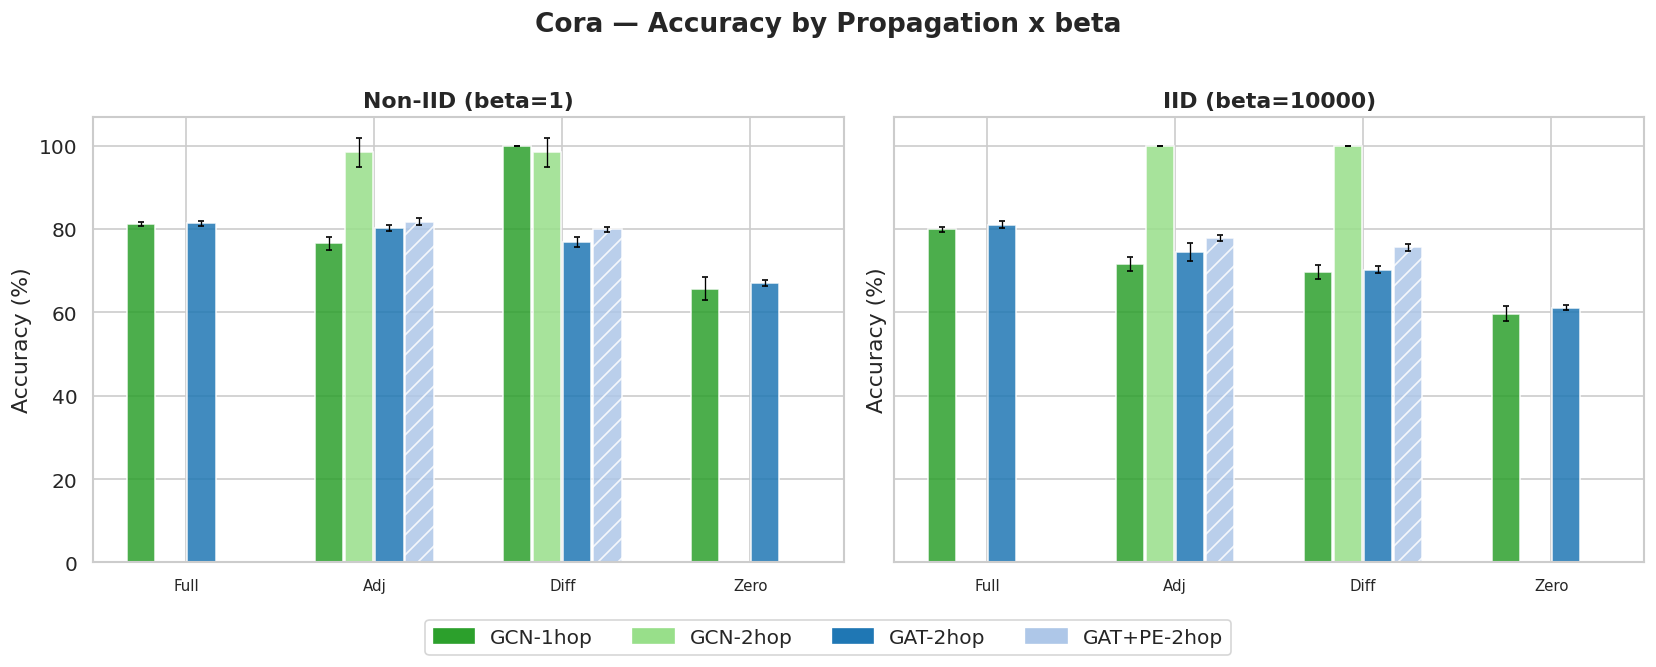

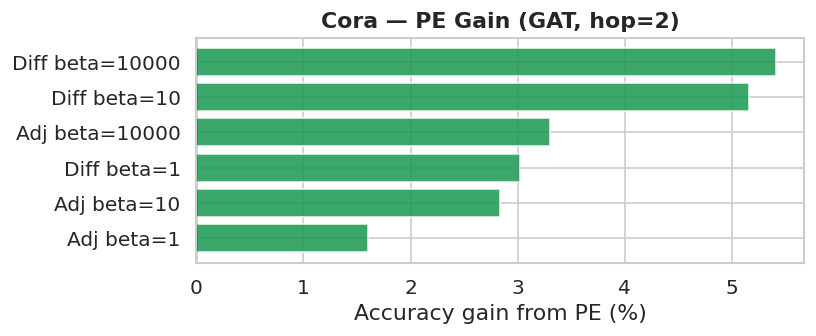

In [13]:
# ── Cora: bar chart (propagation × β, 1-hop vs 2-hop) ──────────────────────
if not (_cora_gcn.empty and _cora_gat.empty and _cora_raw.empty):
    _ds_bar('Cora', _cora_gcn, _cora_gat, _cora_raw)
    _ds_pe_gain('Cora', _cora_gat)
else:
    print('No data yet for Cora — run the configs listed above.')

---
## Citeseer
<a id='ds-citeseer'></a>

| h | #Nodes | #Edges | #Classes | #Features |
|---|--------|--------|----------|-----------|
| 0.74 | 3,327 | 9,228 | 6 | 3,703 |

**Configs:** `conf/citeseer_config.yaml` · `conf/citeseer/citeseer_gcn_beta1.yaml` · `conf/citeseer/citeseer_gcn_beta10000.yaml` · `conf/citeseer/citeseer_gat_beta1.yaml` · `conf/citeseer/citeseer_gat_beta10000.yaml`  
**Batches (all\_results/):** `R1_Citeseer_GCN_1hop_nope` · `R1_Citeseer_GCN_1hop_pe` · `R1b_Citeseer_GAT_2hop_nope` · `R1b_Citeseer_GAT_2hop_pe` · `prelim_Citeseer_2hop`  
**1-hop status:** 🟢 R1 consolidated (GCN, hop=1)  
**2-hop status:** 🟢 R1b consolidated (GAT, hop=2) · 🟡 prelim (1 rep)

In [14]:
# ── Citeseer: load ─────────────────────────────────────────────────────────────
_citeseer_gcn, _citeseer_gat, _citeseer_raw = _ds_data('Citeseer', [])
print(f'GCN (R1 consolidated, hop=1) : {len(_citeseer_gcn)} configs')
print(f'GAT (R1b consolidated, hop=2): {len(_citeseer_gat)} configs')
print(f'Raw scan (all_results)        : {len(_citeseer_raw)} configs')

GCN (R1 consolidated, hop=1) : 11 configs
GAT (R1b consolidated, hop=2): 18 configs
Raw scan (all_results)        : 69 configs


In [15]:
# ── Citeseer: summary table ────────────────────────────────────────────────────
_ds_table('Citeseer', _citeseer_gcn, _citeseer_gat, _citeseer_raw)

,Source,Model,Hop,Prop,β,PE,Reps,Result
0,prelim_Citeseer_2hop,GCN,2,Diff,10000,False,1,100.0 ± 0.0
1,prelim_Citeseer_2hop,GCN,2,Diff,10000,True,1,100.0 ± 0.0
2,prelim_Citeseer_2hop,GCN,2,Diff,1,False,1,100.0 ± 0.0
3,R1_Citeseer_GCN_1hop_nope,GCN,1,Diff,1,False,1,100.0 ± 0.0
4,prelim_Citeseer_2hop,GCN,2,Adj,10000,True,1,100.0 ± 0.0
5,prelim_Citeseer_2hop,GCN,2,Full,1,False,2,99.7 ± 0.9
6,prelim_Citeseer_2hop,GCN,2,Diff,1,True,1,99.5 ± 1.5
7,prelim_Citeseer_2hop,GCN,2,Full,10000,False,2,99.4 ± 1.7
8,prelim_Citeseer_2hop,GCN,2,Adj,1,True,1,99.1 ± 2.7
9,prelim_Citeseer_2hop,GCN,2,Adj,10000,False,1,98.9 ± 3.3


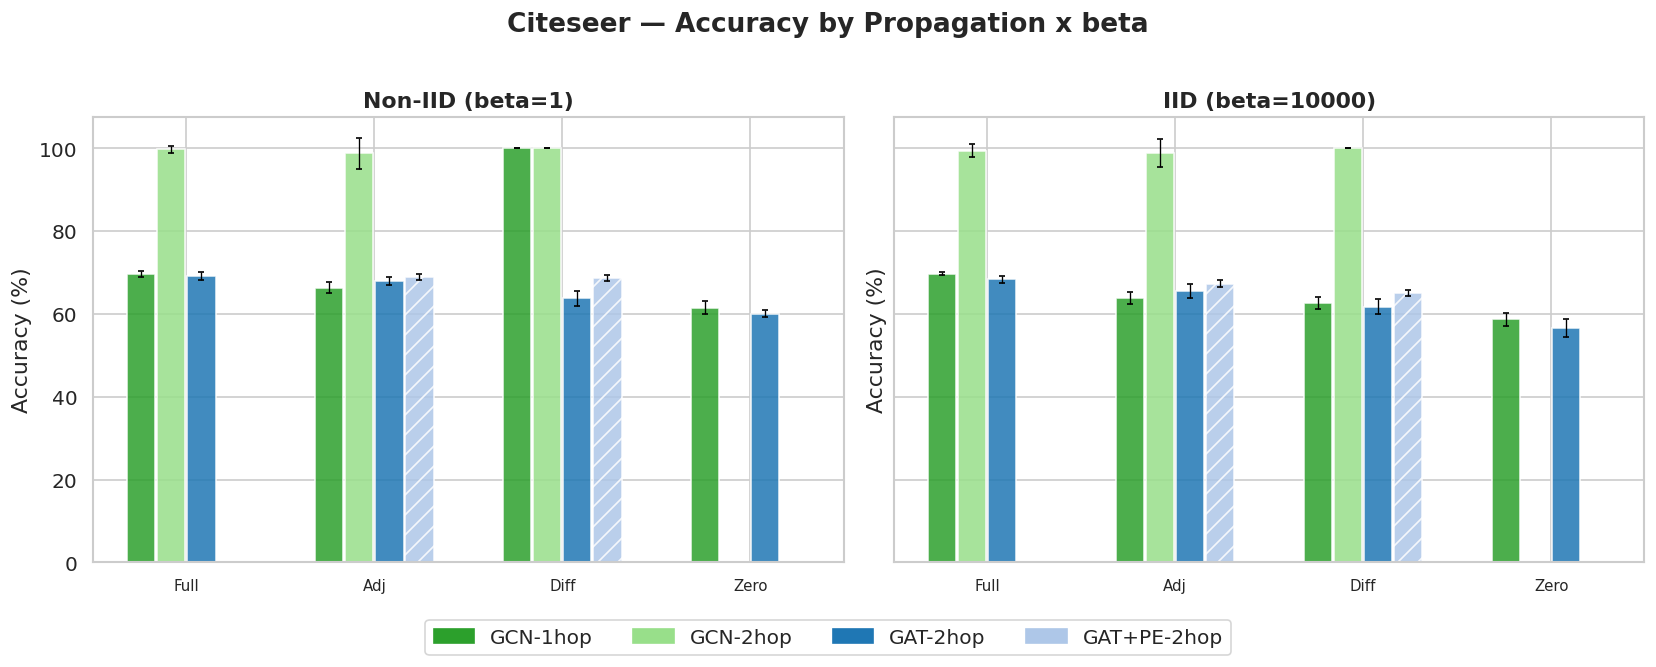

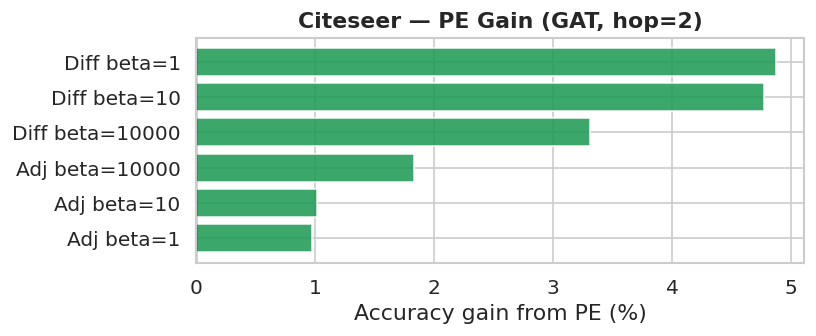

In [16]:
# ── Citeseer: bar chart (propagation × β, 1-hop vs 2-hop) ──────────────────────
if not (_citeseer_gcn.empty and _citeseer_gat.empty and _citeseer_raw.empty):
    _ds_bar('Citeseer', _citeseer_gcn, _citeseer_gat, _citeseer_raw)
    _ds_pe_gain('Citeseer', _citeseer_gat)
else:
    print('No data yet for Citeseer — run the configs listed above.')

---
## Pubmed
<a id='ds-pubmed'></a>

| h | #Nodes | #Edges | #Classes | #Features |
|---|--------|--------|----------|-----------|
| 0.8 | 19,717 | 88,648 | 3 | 500 |

**Configs:** `conf/pubmed_config.yaml` · `conf/pubmed/pubmed_gcn_beta1.yaml` · `conf/pubmed/pubmed_gcn_beta10000.yaml` · `conf/pubmed/pubmed_gat_beta1.yaml` · `conf/pubmed/pubmed_gat_beta10000.yaml`  
**Batches (all\_results/):** `R1_Pubmed_GCN_1hop_nope` · `R1_Pubmed_GCN_1hop_pe` · `R1b_Pubmed_GAT_2hop_nope` · `R1b_Pubmed_GAT_2hop_pe` · `R1b_Pubmed_GAT_pe_adj` · `R1b_Pubmed_GAT_pe_diff` · `prelim_Pubmed_2hop`  
**1-hop status:** 🟢 R1 consolidated (GCN, hop=1)  
**2-hop status:** 🟢 R1b consolidated (GAT, hop=2) · 🟡 prelim (1 rep)

In [17]:
# ── Pubmed: load ─────────────────────────────────────────────────────────────
_pubmed_gcn, _pubmed_gat, _pubmed_raw = _ds_data('Pubmed', [])
print(f'GCN (R1 consolidated, hop=1) : {len(_pubmed_gcn)} configs')
print(f'GAT (R1b consolidated, hop=2): {len(_pubmed_gat)} configs')
print(f'Raw scan (all_results)        : {len(_pubmed_raw)} configs')

GCN (R1 consolidated, hop=1) : 11 configs
GAT (R1b consolidated, hop=2): 18 configs
Raw scan (all_results)        : 67 configs


In [18]:
# ── Pubmed: summary table ────────────────────────────────────────────────────
_ds_table('Pubmed', _pubmed_gcn, _pubmed_gat, _pubmed_raw)

,Source,Model,Hop,Prop,β,PE,Reps,Result
0,R1_Pubmed_GCN_1hop_nope,GCN,1,Zero,1,False,1,98.8 ± 2.4
1,prelim_Pubmed_2hop,GCN,2,Adj,10,True,1,98.3 ± 5.0
2,prelim_Pubmed_2hop,GCN,2,Diff,10000,True,1,97.5 ± 7.5
3,prelim_Pubmed_2hop,GCN,2,Diff,10000,False,1,96.5 ± 7.8
4,prelim_Pubmed_2hop,GCN,2,Diff,10,True,1,96.3 ± 7.4
5,prelim_Pubmed_2hop,GCN,2,Diff,10,False,1,96.3 ± 7.4
6,prelim_Pubmed_2hop,GCN,2,Adj,10000,False,1,95.5 ± 9.1
7,prelim_Pubmed_2hop,GCN,2,Adj,10000,True,1,95.0 ± 15.0
8,prelim_Pubmed_2hop,GCN,2,Adj,10,False,1,92.9 ± 8.8
9,R1b-cons,GAT,2,Adj,10000,False,10,79.4 ± 0.6


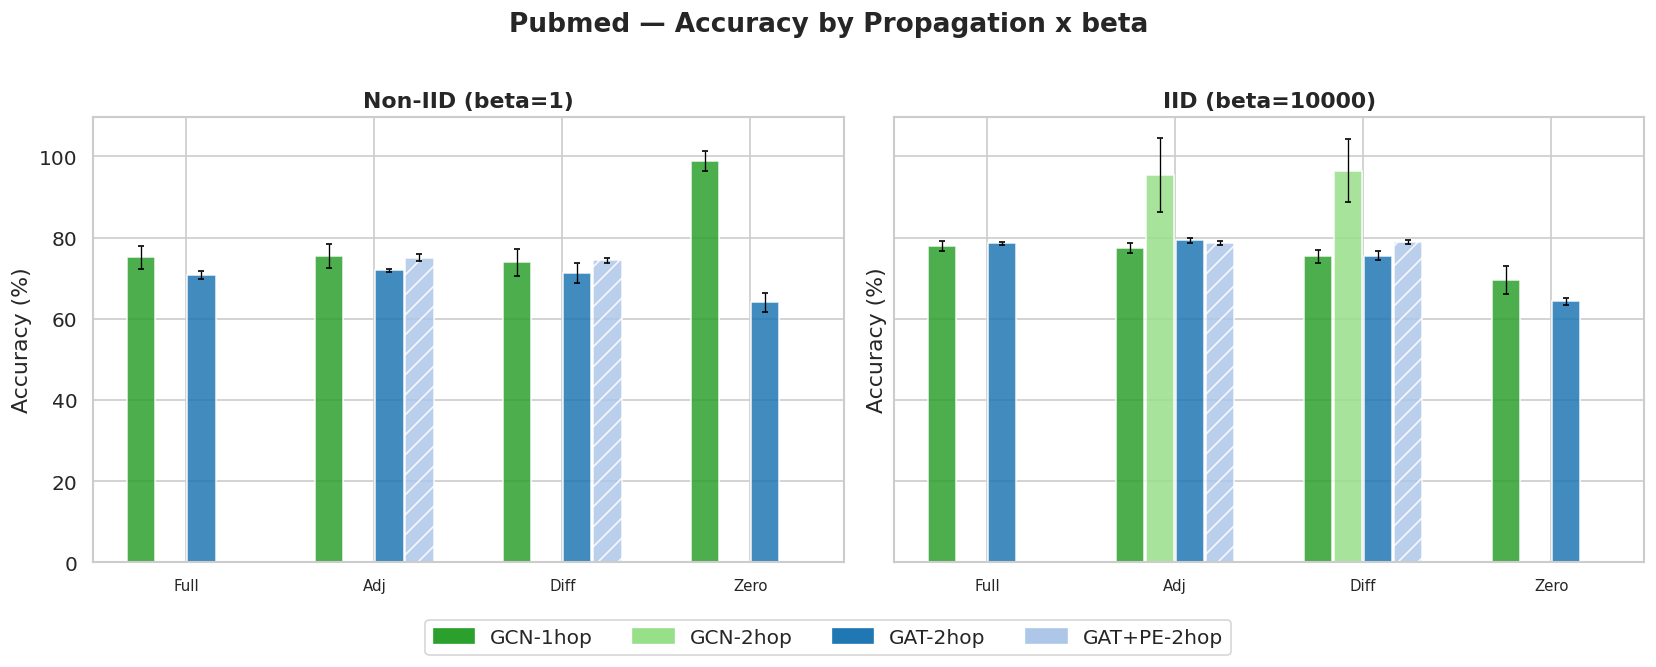

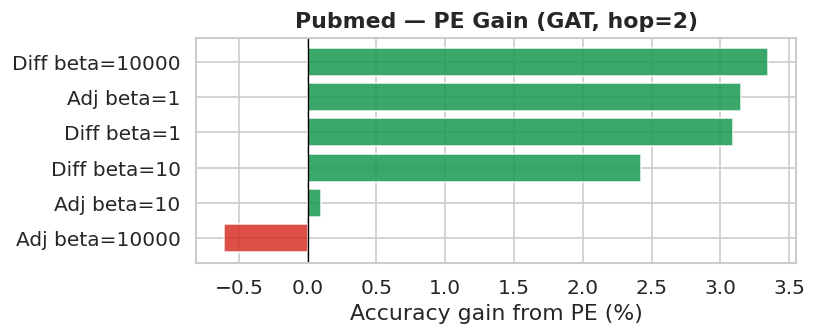

In [19]:
# ── Pubmed: bar chart (propagation × β, 1-hop vs 2-hop) ──────────────────────
if not (_pubmed_gcn.empty and _pubmed_gat.empty and _pubmed_raw.empty):
    _ds_bar('Pubmed', _pubmed_gcn, _pubmed_gat, _pubmed_raw)
    _ds_pe_gain('Pubmed', _pubmed_gat)
else:
    print('No data yet for Pubmed — run the configs listed above.')

---
## OGBN-Arxiv
<a id='ds-ogbn'></a>

| h | #Nodes | #Edges | #Classes | #Features |
|---|--------|--------|----------|-----------|
| 0.66 | 169,343 | 1,166,243 | 40 | 128 |

**Configs:** `conf/ogbn-arxiv_config.yaml` · `conf/ogbn-arxiv_config_gat.yaml` · `conf/ogbn-arxiv_zero_full.yaml`  
**Batches (all\_results/):** `OGBN_adj_diff_nope` · `OGBN_adj_diff_pe` · `OGBN_adj_diff2` · `OGBN_zero_full` · `OGBN_zero_full2` · `OGBN_scalability_validation`  
**1-hop status:** 🔴 not yet  
**2-hop status:** 🟡 partial (GCN only, ~1-2 reps per config)

In [20]:
# ── OGBN-Arxiv: load ─────────────────────────────────────────────────────────────
_ogbn_gcn, _ogbn_gat, _ogbn_raw = _ds_data('OGBN-Arxiv', ['ogbn-arxiv'])
print(f'GCN (R1 consolidated, hop=1) : {len(_ogbn_gcn)} configs')
print(f'GAT (R1b consolidated, hop=2): {len(_ogbn_gat)} configs')
print(f'Raw scan (all_results)        : {len(_ogbn_raw)} configs')

GCN (R1 consolidated, hop=1) : 0 configs
GAT (R1b consolidated, hop=2): 0 configs
Raw scan (all_results)        : 18 configs


In [21]:
# ── OGBN-Arxiv: summary table ────────────────────────────────────────────────────
_ds_table('OGBN-Arxiv', _ogbn_gcn, _ogbn_gat, _ogbn_raw)

,Source,Model,Hop,Prop,β,PE,Reps,Result
0,OGBN_scalability_validation,GCN,2,Full,10000,False,10,87.1 ± 0.2
1,OGBN_adj_diff_pe,GCN,2,Diff,1,True,1,86.3 ± 4.6
2,OGBN_adj_diff_pe,GCN,2,Adj,1,True,1,86.3 ± 4.5
3,OGBN_adj_diff_pe,GCN,2,Diff,10000,True,1,85.3 ± 0.3
4,OGBN_adj_diff_pe,GCN,2,Adj,10000,True,1,82.6 ± 0.4
5,OGBN_adj_diff2,GCN,2,Adj,1,False,1,81.8 ± 5.5
6,OGBN_adj_diff2,GCN,2,Diff,1,False,1,80.4 ± 5.7
7,OGBN_adj_diff2,GCN,2,Diff,10000,False,1,79.8 ± 0.5
8,OGBN_zero_full,GCN,2,Full,1,False,1,79.5 ± 6.0
9,OGBN_adj_diff2,GCN,2,Adj,10000,False,1,79.3 ± 0.6


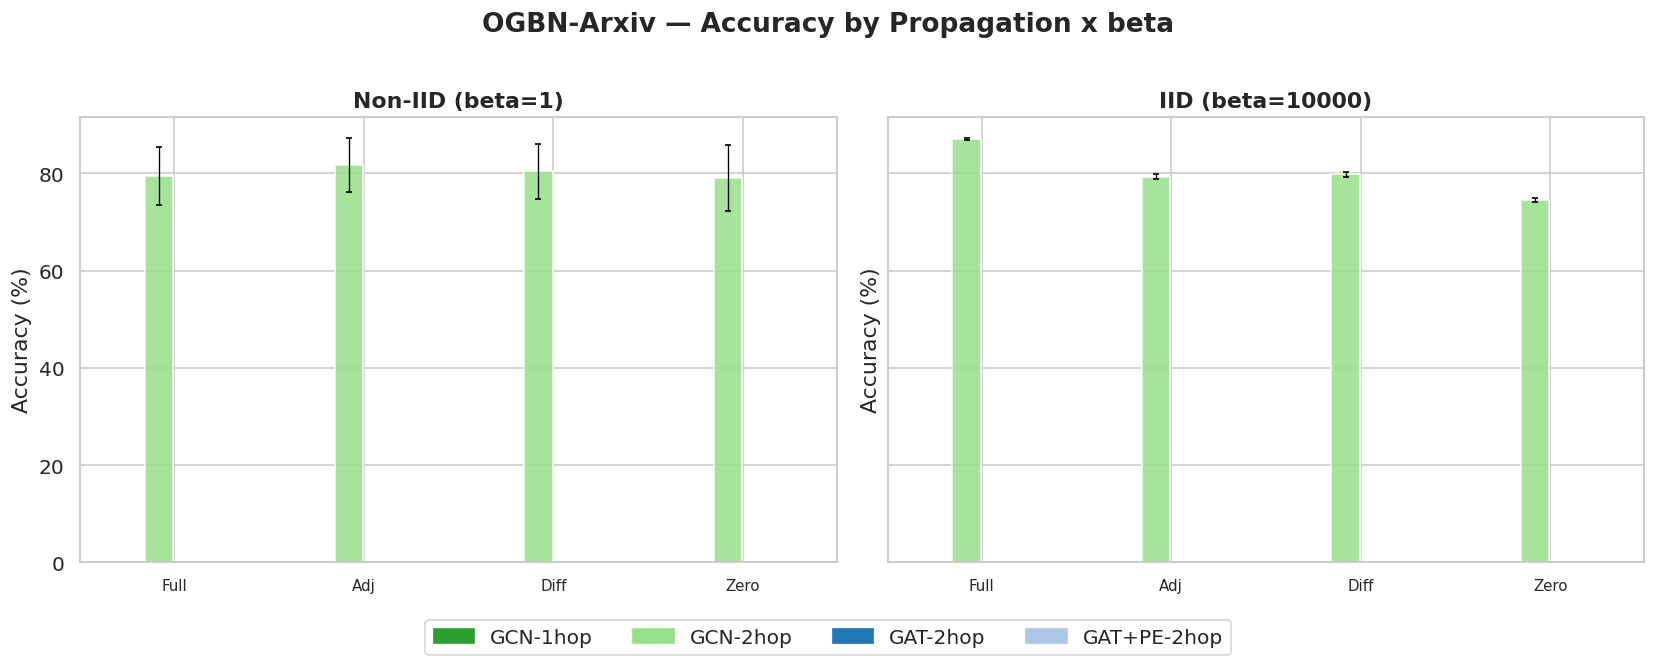

No GAT data for OGBN-Arxiv PE gain chart


In [22]:
# ── OGBN-Arxiv: bar chart (propagation × β, 1-hop vs 2-hop) ──────────────────────
if not (_ogbn_gcn.empty and _ogbn_gat.empty and _ogbn_raw.empty):
    _ds_bar('OGBN-Arxiv', _ogbn_gcn, _ogbn_gat, _ogbn_raw)
    _ds_pe_gain('OGBN-Arxiv', _ogbn_gat)
else:
    print('No data yet for OGBN-Arxiv — run the configs listed above.')

---
## Amazon Computers
<a id='ds-amazon_comp'></a>

| h | #Nodes | #Edges | #Classes | #Features |
|---|--------|--------|----------|-----------|
| 0.78 | 13,752 | 574,418 | 10 | 767 |

**Configs:** `conf/computers_config.yaml`  
**Batches (all\_results/):** *none yet*  
**1-hop status:** 🔴 to run  
**2-hop status:** 🔴 to run

In [23]:
# ── Amazon Computers: load ─────────────────────────────────────────────────────────────
_amazon_comp_gcn, _amazon_comp_gat, _amazon_comp_raw = _ds_data('Amazon Computers', ['Computers'])
print(f'GCN (R1 consolidated, hop=1) : {len(_amazon_comp_gcn)} configs')
print(f'GAT (R1b consolidated, hop=2): {len(_amazon_comp_gat)} configs')
print(f'Raw scan (all_results)        : {len(_amazon_comp_raw)} configs')

GCN (R1 consolidated, hop=1) : 0 configs
GAT (R1b consolidated, hop=2): 0 configs
Raw scan (all_results)        : 0 configs


In [24]:
# ── Amazon Computers: summary table ────────────────────────────────────────────────────
_ds_table('Amazon Computers', _amazon_comp_gcn, _amazon_comp_gat, _amazon_comp_raw)

No data for Amazon Computers


In [25]:
# ── Amazon Computers: placeholder (no data yet) ────────────────────────────────────────
print('No results yet for Amazon Computers.')
print('Run configs: conf/computers_config.yaml')
# When data is available, uncomment:
# _ds_bar('Amazon Computers', _amazon_comp_gcn, _amazon_comp_gat, _amazon_comp_raw)
# _ds_pe_gain('Amazon Computers', _amazon_comp_gat)

No results yet for Amazon Computers.
Run configs: conf/computers_config.yaml


---
## Amazon Photos
<a id='ds-amazon_photos'></a>

| h | #Nodes | #Edges | #Classes | #Features |
|---|--------|--------|----------|-----------|
| 0.83 | 7,650 | 238,162 | 8 | 745 |

**Configs:** `conf/photos_config.yaml`  
**Batches (all\_results/):** *none yet*  
**1-hop status:** 🔴 to run  
**2-hop status:** 🔴 to run

In [26]:
# ── Amazon Photos: load ─────────────────────────────────────────────────────────────
_amazon_photos_gcn, _amazon_photos_gat, _amazon_photos_raw = _ds_data('Amazon Photos', ['Photos'])
print(f'GCN (R1 consolidated, hop=1) : {len(_amazon_photos_gcn)} configs')
print(f'GAT (R1b consolidated, hop=2): {len(_amazon_photos_gat)} configs')
print(f'Raw scan (all_results)        : {len(_amazon_photos_raw)} configs')

GCN (R1 consolidated, hop=1) : 0 configs
GAT (R1b consolidated, hop=2): 0 configs
Raw scan (all_results)        : 0 configs


In [27]:
# ── Amazon Photos: summary table ────────────────────────────────────────────────────
_ds_table('Amazon Photos', _amazon_photos_gcn, _amazon_photos_gat, _amazon_photos_raw)

No data for Amazon Photos


In [28]:
# ── Amazon Photos: placeholder (no data yet) ────────────────────────────────────────
print('No results yet for Amazon Photos.')
print('Run configs: conf/photos_config.yaml')
# When data is available, uncomment:
# _ds_bar('Amazon Photos', _amazon_photos_gcn, _amazon_photos_gat, _amazon_photos_raw)
# _ds_pe_gain('Amazon Photos', _amazon_photos_gat)

No results yet for Amazon Photos.
Run configs: conf/photos_config.yaml


---
## Texas
<a id='ds-texas'></a>

| h | #Nodes | #Edges | #Classes | #Features |
|---|--------|--------|----------|-----------|
| 0.11 | 183 | 325 | 5 | 1,703 |

**Configs:** `conf/texas_gcn_beta1.yaml (to create)`  
**Batches (all\_results/):** *none yet*  
**1-hop status:** 🔴 to run  
**2-hop status:** 🔴 to run

In [29]:
# ── Texas: load ─────────────────────────────────────────────────────────────
_texas_gcn, _texas_gat, _texas_raw = _ds_data('Texas', [])
print(f'GCN (R1 consolidated, hop=1) : {len(_texas_gcn)} configs')
print(f'GAT (R1b consolidated, hop=2): {len(_texas_gat)} configs')
print(f'Raw scan (all_results)        : {len(_texas_raw)} configs')

GCN (R1 consolidated, hop=1) : 0 configs
GAT (R1b consolidated, hop=2): 0 configs
Raw scan (all_results)        : 0 configs


In [30]:
# ── Texas: summary table ────────────────────────────────────────────────────
_ds_table('Texas', _texas_gcn, _texas_gat, _texas_raw)

No data for Texas


In [31]:
# ── Texas: placeholder (no data yet) ────────────────────────────────────────
print('No results yet for Texas.')
print('Run configs: conf/texas_gcn_beta1.yaml (to create)')
# When data is available, uncomment:
# _ds_bar('Texas', _texas_gcn, _texas_gat, _texas_raw)
# _ds_pe_gain('Texas', _texas_gat)

No results yet for Texas.
Run configs: conf/texas_gcn_beta1.yaml (to create)


---
## Wisconsin
<a id='ds-wisconsin'></a>

| h | #Nodes | #Edges | #Classes | #Features |
|---|--------|--------|----------|-----------|
| 0.2 | 251 | 515 | 5 | 1,703 |

**Configs:** `conf/wisconsin_gcn_beta1.yaml (to create)`  
**Batches (all\_results/):** *none yet*  
**1-hop status:** 🔴 to run  
**2-hop status:** 🔴 to run

In [32]:
# ── Wisconsin: load ─────────────────────────────────────────────────────────────
_wisconsin_gcn, _wisconsin_gat, _wisconsin_raw = _ds_data('Wisconsin', [])
print(f'GCN (R1 consolidated, hop=1) : {len(_wisconsin_gcn)} configs')
print(f'GAT (R1b consolidated, hop=2): {len(_wisconsin_gat)} configs')
print(f'Raw scan (all_results)        : {len(_wisconsin_raw)} configs')

GCN (R1 consolidated, hop=1) : 0 configs
GAT (R1b consolidated, hop=2): 0 configs
Raw scan (all_results)        : 0 configs


In [33]:
# ── Wisconsin: summary table ────────────────────────────────────────────────────
_ds_table('Wisconsin', _wisconsin_gcn, _wisconsin_gat, _wisconsin_raw)

No data for Wisconsin


In [34]:
# ── Wisconsin: placeholder (no data yet) ────────────────────────────────────────
print('No results yet for Wisconsin.')
print('Run configs: conf/wisconsin_gcn_beta1.yaml (to create)')
# When data is available, uncomment:
# _ds_bar('Wisconsin', _wisconsin_gcn, _wisconsin_gat, _wisconsin_raw)
# _ds_pe_gain('Wisconsin', _wisconsin_gat)

No results yet for Wisconsin.
Run configs: conf/wisconsin_gcn_beta1.yaml (to create)


---
# Combined Analysis — Tables & Figures
<a id='B'></a>

## B1 · Table 1: Main Accuracy — 6 Datasets × IID / Non-IID
🟡 **Partial** — Cora / Citeseer / Pubmed / OGBN done. Amazon write-up needed. FedSage+ pending (D5).

In [35]:
# Config paths for main GCN runs
B1_CONFIGS = {
    'Cora    Non-IID (β=1)'   : CONF_DIR / 'cora/cora_gcn_beta1.yaml',
    'Cora    IID    (β=10000)': CONF_DIR / 'cora/cora_gcn_beta10000.yaml',
    'Citeseer Non-IID'        : CONF_DIR / 'citeseer/citeseer_gcn_beta1.yaml',
    'Citeseer IID'            : CONF_DIR / 'citeseer/citeseer_gcn_beta10000.yaml',
    'Pubmed  Non-IID'         : CONF_DIR / 'pubmed/pubmed_gcn_beta1.yaml',
    'Pubmed  IID'             : CONF_DIR / 'pubmed/pubmed_gcn_beta10000.yaml',
    'OGBN-Arxiv'              : CONF_DIR / 'ogbn-arxiv_config.yaml',
    'Amazon Computers'        : CONF_DIR / 'computers_config.yaml',
    'Amazon Photos'           : CONF_DIR / 'photos_config.yaml',
}

# Results dirs
B1_RESULTS_DIRS = {
    'Cora/Citeseer/Pubmed GCN'  : RESULTS / 'R1_cora_nope',
    'OGBN-Arxiv'                : RESULTS / 'ogbn-arxiv',
    'Prelim (hop2 runs)'        : EXPT_DIR / 'cora_results_test',
}

for label, p in B1_CONFIGS.items():
    status = '✓' if Path(p).exists() else '✗ MISSING'
    print(f'  {status}  {label:30s}  {p}')

  ✓  Cora    Non-IID (β=1)           /home/bosho/FP/conf/cora/cora_gcn_beta1.yaml
  ✓  Cora    IID    (β=10000)        /home/bosho/FP/conf/cora/cora_gcn_beta10000.yaml
  ✓  Citeseer Non-IID                /home/bosho/FP/conf/citeseer/citeseer_gcn_beta1.yaml
  ✓  Citeseer IID                    /home/bosho/FP/conf/citeseer/citeseer_gcn_beta10000.yaml
  ✓  Pubmed  Non-IID                 /home/bosho/FP/conf/pubmed/pubmed_gcn_beta1.yaml
  ✓  Pubmed  IID                     /home/bosho/FP/conf/pubmed/pubmed_gcn_beta10000.yaml
  ✓  OGBN-Arxiv                      /home/bosho/FP/conf/ogbn-arxiv_config.yaml
  ✓  Amazon Computers                /home/bosho/FP/conf/computers_config.yaml
  ✓  Amazon Photos                   /home/bosho/FP/conf/photos_config.yaml


In [36]:
# ── B1: Build the main accuracy table from R1 consolidated (GCN) ─────────────
# Best FedProp variant = max accuracy per dataset×setting
# IID ≈ β=10000, Non-IID ≈ β=1

BETA_IID    = 10000
BETA_NONIID = 1

def best_fedprop(df, dataset, beta):
    sub = df[(df['dataset']==dataset) & (df['beta']==beta)]
    if sub.empty: return np.nan, np.nan, '—'
    row = sub.loc[sub['acc_pct'].idxmax()]
    label = f"{PROP_LABELS.get(row['propagation'], row['propagation'])}"
    if row.get('use_pe', False): label += '+PE'
    return float(row['acc_pct']), float(row['std_pct']), label

# Published / manually entered baselines (fill from papers)
# Format: {method: {(dataset, setting): (mean_acc, std_acc) or None}}
PUBLISHED_BASELINES = {
    'Centralized': {
        ('Cora','IID'):84.9,'Cora_Non-IID':84.9,
        ('Citeseer','IID'):73.3,('Citeseer','Non-IID'):73.3,
        ('Pubmed','IID'):86.7,('Pubmed','Non-IID'):86.7,
    },
    'FedGCN'  : {},  # TODO: fill from paper
    'FedGAT'  : {},
    'DistGAT' : {},
    'FedSage+': {},  # TODO: from D5
}

rows_table = []
for ds in ['Cora','Citeseer','Pubmed']:
    for setting, beta in [('Non-IID', BETA_NONIID), ('IID', BETA_IID)]:
        acc, std, best_var = best_fedprop(r1, ds, beta)
        rows_table.append({
            'Dataset': ds, 'Setting': setting,
            'FedProp Best': f'{acc:.1f} ± {std:.1f}' if not np.isnan(acc) else '—',
            'Variant': best_var,
            'FedProp-Zero': None,  # fill from R1 zero_hop row
            'FedProp-Full': None,
        })
        # Fill zero / full
        for prop in ['zero_hop','full']:
            sub = r1[(r1['dataset']==ds)&(r1['beta']==beta)&(r1['propagation']==prop)]
            val = f"{sub['acc_pct'].mean():.1f}" if not sub.empty else '—'
            key = 'FedProp-Zero' if prop=='zero_hop' else 'FedProp-Full'
            rows_table[-1][key] = val

b1_table = pd.DataFrame(rows_table)
display(b1_table)

,Dataset,Setting,FedProp Best,Variant,FedProp-Zero,FedProp-Full
0,Cora,Non-IID,81.1 ± 0.5,Full,65.7,81.1
1,Cora,IID,79.9 ± 0.7,Full,59.7,79.9
2,Citeseer,Non-IID,69.6 ± 0.8,Full,61.5,69.6
3,Citeseer,IID,69.7 ± 0.4,Full,58.7,69.7
4,Pubmed,Non-IID,75.4 ± 3.0,Adj,—,75.1
5,Pubmed,IID,77.9 ± 1.1,Full,69.6,77.9


In [37]:
# ── B1: Recovery % computation ──────────────────────────────────────────────
# Recovery % = (FedProp − Zero) / (Centralized − Zero)
CENTRALIZED = {'Cora':84.9, 'Citeseer':73.3, 'Pubmed':86.7, 'ogbn-arxiv':71.5}

recovery_rows = []
for ds in ['Cora','Citeseer','Pubmed']:
    cent = CENTRALIZED.get(ds, np.nan)
    for setting, beta in [('Non-IID', BETA_NONIID), ('IID', BETA_IID)]:
        zero_sub = r1[(r1['dataset']==ds)&(r1['beta']==beta)&(r1['propagation']=='zero_hop')]
        best_sub = r1[(r1['dataset']==ds)&(r1['beta']==beta)]
        if zero_sub.empty or best_sub.empty: continue
        zero_acc = zero_sub['acc_pct'].mean()
        best_acc = best_sub['acc_pct'].max()
        rec = (best_acc - zero_acc) / (cent - zero_acc) * 100 if cent != zero_acc else np.nan
        recovery_rows.append({'Dataset':ds,'Setting':setting,
                              'Zero':round(zero_acc,1),'Best':round(best_acc,1),
                              'Centralized':cent,'Recovery%':round(rec,1)})

rec_df = pd.DataFrame(recovery_rows)
print('Recovery % (FedProp best vs centralized ceiling):')
display(rec_df)

Recovery % (FedProp best vs centralized ceiling):


,Dataset,Setting,Zero,Best,Centralized,Recovery%
0,Cora,Non-IID,65.7,81.1,84.9,80.3
1,Cora,IID,59.7,79.9,84.9,80.2
2,Citeseer,Non-IID,61.5,69.6,73.3,68.6
3,Citeseer,IID,58.7,69.7,73.3,75.5
4,Pubmed,IID,69.6,77.9,86.7,48.6


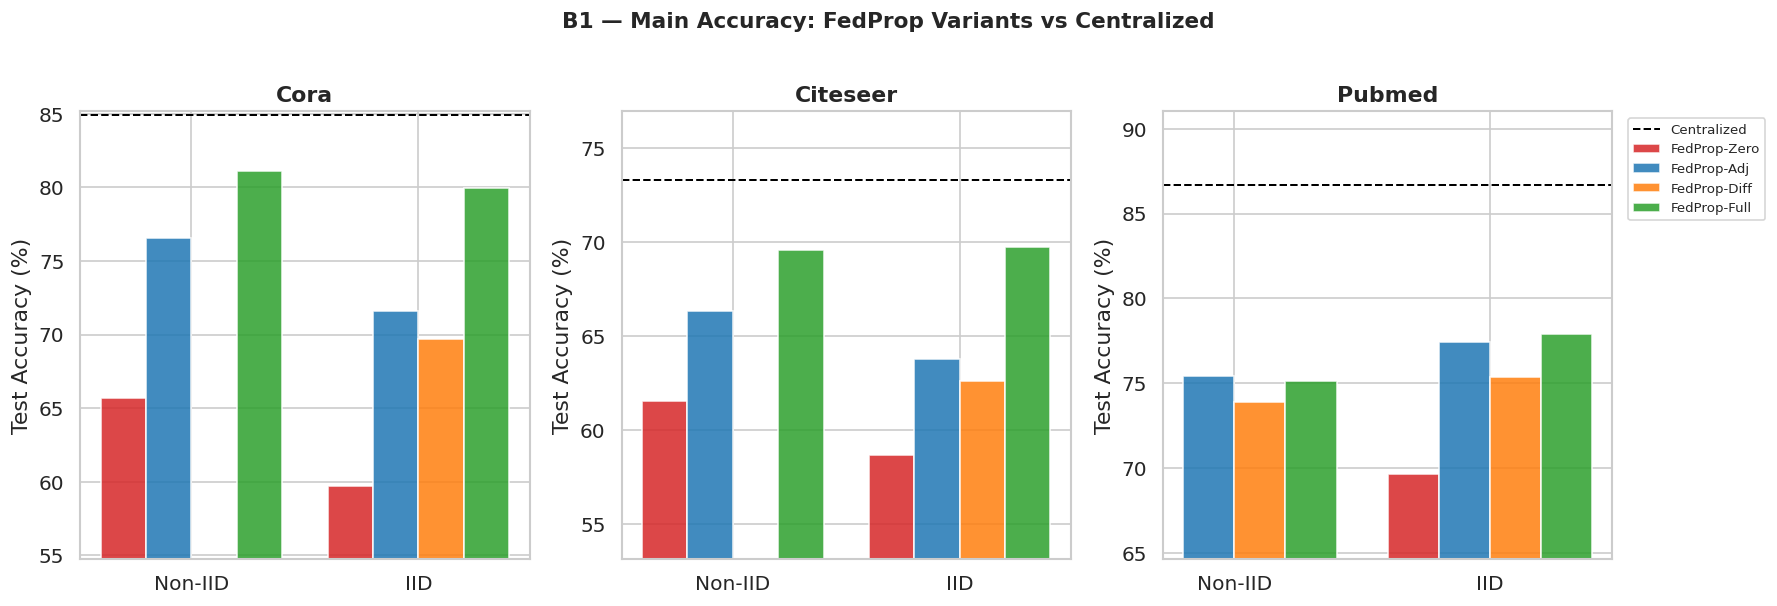

In [38]:
# ── B1: Visual summary — bar chart with recovery % overlay ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
datasets = ['Cora','Citeseer','Pubmed']
settings = ['Non-IID','IID']
x = np.arange(len(settings))
width = 0.2

for ax, ds in zip(axes, datasets):
    cent = CENTRALIZED.get(ds, np.nan)
    for i, (prop, label, color) in enumerate([
        ('zero_hop','FedProp-Zero', COLORS[3]),
        ('adjacency','FedProp-Adj', COLORS[0]),
        ('diffusion','FedProp-Diff', COLORS[1]),
        ('full',     'FedProp-Full', COLORS[2]),
    ]):
        vals = []
        for setting, beta in [('Non-IID', BETA_NONIID), ('IID', BETA_IID)]:
            sub = r1[(r1['dataset']==ds)&(r1['beta']==beta)&(r1['propagation']==prop)]
            vals.append(sub['acc_pct'].mean() if not sub.empty else np.nan)
        ax.bar(x + i*width, vals, width, label=label, color=color, alpha=0.85)

    ax.axhline(cent, color='black', linestyle='--', linewidth=1.2, label='Centralized')
    ax.set_xticks(x + 1.5*width)
    ax.set_xticklabels(settings)
    ax.set_title(ds, fontweight='bold')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_ylim(bottom=max(0, r1[r1['dataset']==ds]['acc_pct'].min()-5))
    if ds == 'Pubmed':
        ax.legend(fontsize=8, bbox_to_anchor=(1.02,1), loc='upper left')

plt.suptitle('B1 — Main Accuracy: FedProp Variants vs Centralized', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## B2 · Table 2: Communication Efficiency — All 6 Datasets
🟡 **Extend** — Current data covers Pubmed only. Need same metric for all 6 datasets.

In [39]:
# Config / results paths for B2
B2_RESULTS_DIR = RESULTS / 'scalability'
print('Scalability results dir exists:', B2_RESULTS_DIR.exists())
print('Subdirs:', [d.name for d in sorted(B2_RESULTS_DIR.iterdir()) if d.is_dir()])

Scalability results dir exists: True
Subdirs: ['full_concurrency_sweep', 'ogbn_arxiv', 'ogbn_arxiv_peak', 'ogbn_arxiv_single_full_validation', 'ogbn_arxiv_smoke', 'ogbn_arxiv_smoke_full']


In [40]:
# ── B2: Comm-efficiency definition and table ─────────────────────────────────
# Communication Efficiency = 1 / comm_cost_relative_to_FedAvg
# FedProp = 1.0 (no additional comm), same as FedAvg baseline
#
# Comm cost per round (relative to FedAvg = 1.0):
#   FedAvg / FedProp: 1.0  (model weights only)
#   FedGCN:  transmits neighbour embeddings  → higher cost
#   FedGAT:  transmits attention embeddings  → higher cost
#   DistGAT: transmits subgraph messages     → higher cost
#   FedSage+: generative model + features    → highest cost
# Fill 'Relative Comm Cost' from published numbers or D9 run

B2_TABLE = pd.DataFrame([
    {'Method':'FedProp (Ours)', 'Relative Comm Cost':1.0,  'Source':'This work — no extra comm'},
    {'Method':'FedGCN',         'Relative Comm Cost':None, 'Source':'TODO: from paper or D9'},
    {'Method':'FedGAT',         'Relative Comm Cost':None, 'Source':'TODO'},
    {'Method':'DistGAT',        'Relative Comm Cost':None, 'Source':'TODO'},
    {'Method':'DGCN',           'Relative Comm Cost':None, 'Source':'TODO'},
    {'Method':'BDS-GCN',        'Relative Comm Cost':None, 'Source':'TODO'},
    {'Method':'FedSage+',       'Relative Comm Cost':None, 'Source':'TODO: from D5'},
])

# Per-dataset accuracy from our results
for ds in ['Cora','Citeseer','Pubmed']:
    best = r1[r1['dataset']==ds]['acc_pct'].max() if not r1[r1['dataset']==ds].empty else np.nan
    B2_TABLE.loc[B2_TABLE['Method']=='FedProp (Ours)', f'{ds} Acc'] = round(best,1)

display(B2_TABLE)
print('\n⚠  Fill Relative Comm Cost from D9 or published numbers to complete this table.')

,Method,Relative Comm Cost,Source,Cora Acc,Citeseer Acc,Pubmed Acc
0,FedProp (Ours),1.0,This work — no extra comm,81.1,69.8,77.9
1,FedGCN,NaN,TODO: from paper or D9,NaN,NaN,NaN
2,FedGAT,NaN,TODO,NaN,NaN,NaN
3,DistGAT,NaN,TODO,NaN,NaN,NaN
4,DGCN,NaN,TODO,NaN,NaN,NaN
5,BDS-GCN,NaN,TODO,NaN,NaN,NaN
6,FedSage+,NaN,TODO: from D5,NaN,NaN,NaN



⚠  Fill Relative Comm Cost from D9 or published numbers to complete this table.


## B3 · Table 3: Backbone Comparison — FedProp-GCN vs FedProp-GAT vs FedGAT
🟢 **Restructure** — All data in R1 / R1b. Restructuring task only.

In [41]:
# Results paths for B3
B3_RESULTS = {
    'GCN (R1)' : OUTPUT / 'R1_consolidated.csv',
    'GAT (R1b)': OUTPUT / 'R1b_consolidated.csv',
}
for k,p in B3_RESULTS.items():
    print(f'  {k}: {"OK" if p.exists() else "MISSING"} — {p}')

  GCN (R1): OK — /home/bosho/FP/experiments/output/R1_consolidated.csv
  GAT (R1b): OK — /home/bosho/FP/experiments/output/R1b_consolidated.csv


In [42]:
# ── B3: Backbone comparison table ────────────────────────────────────────────
b3_rows = []
for ds in ['Cora','Citeseer','Pubmed']:
    for setting, beta in [('IID', BETA_IID),('Non-IID', BETA_NONIID)]:
        # GCN best
        gcn_sub = r1[(r1['dataset']==ds)&(r1['beta']==beta)]
        gcn_best = gcn_sub['acc_pct'].max() if not gcn_sub.empty else np.nan

        # GAT best (no PE)
        gat_sub = r1b[(r1b['dataset']==ds)&(r1b['beta']==beta)&(~r1b['use_pe'])]
        gat_best = gat_sub['acc_pct'].max() if not gat_sub.empty else np.nan

        # GAT+PE best
        gat_pe_sub = r1b[(r1b['dataset']==ds)&(r1b['beta']==beta)&(r1b['use_pe'])]
        gat_pe_best = gat_pe_sub['acc_pct'].max() if not gat_pe_sub.empty else np.nan

        b3_rows.append({'Dataset':ds,'Setting':setting,
                        'FedProp-GCN':round(gcn_best,1),
                        'FedProp-GAT':round(gat_best,1),
                        'FedProp-GAT+PE':round(gat_pe_best,1),
                        'FedGAT (baseline)':'TODO (D5)'})

b3_df = pd.DataFrame(b3_rows)
display(b3_df)

,Dataset,Setting,FedProp-GCN,FedProp-GAT,FedProp-GAT+PE,FedGAT (baseline)
0,Cora,IID,79.9,81.0,77.8,TODO (D5)
1,Cora,Non-IID,81.1,81.4,81.8,TODO (D5)
2,Citeseer,IID,69.7,68.3,67.3,TODO (D5)
3,Citeseer,Non-IID,69.6,69.1,69.0,TODO (D5)
4,Pubmed,IID,77.9,79.4,78.9,TODO (D5)
5,Pubmed,Non-IID,75.4,71.9,75.1,TODO (D5)


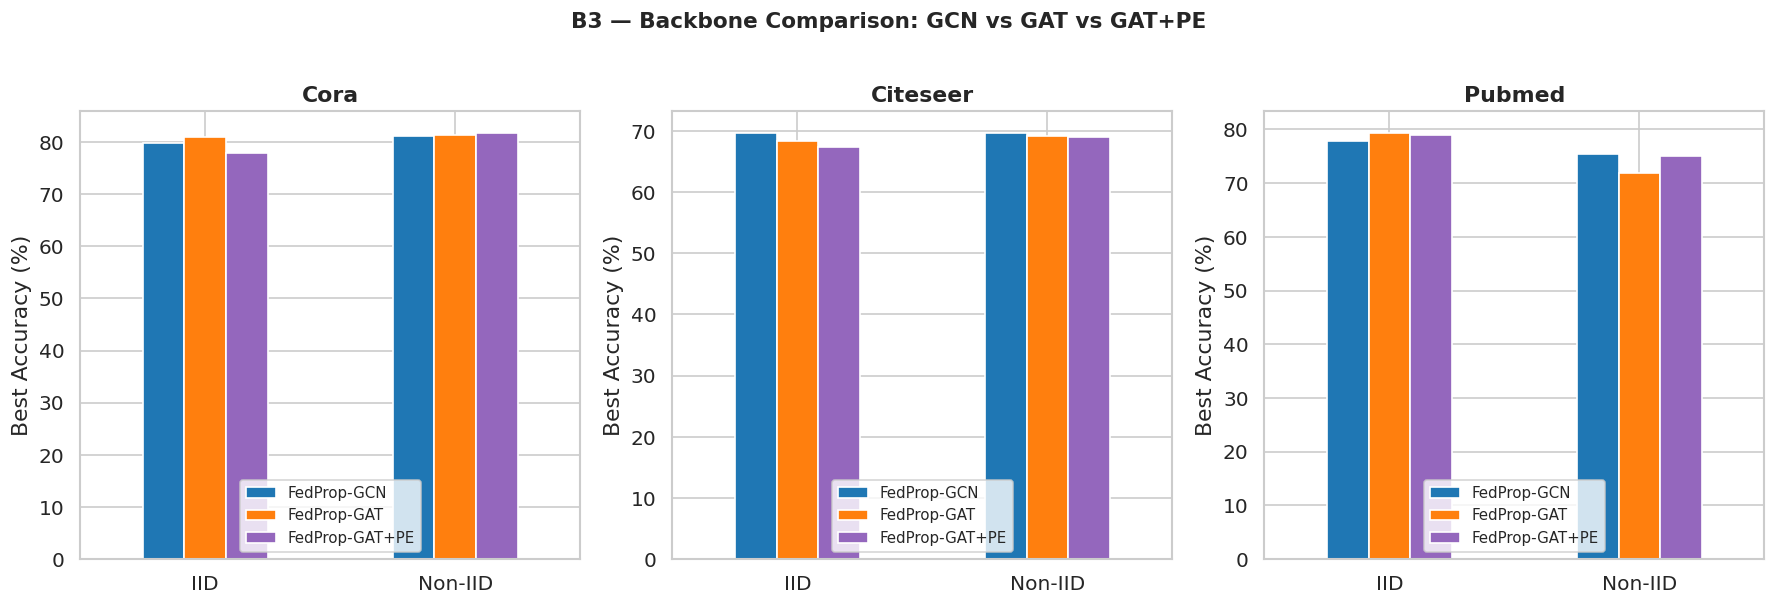

In [43]:
# ── B3: Visual comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ds in zip(axes, ['Cora','Citeseer','Pubmed']):
    sub = b3_df[b3_df['Dataset']==ds].set_index('Setting')
    cols = ['FedProp-GCN','FedProp-GAT','FedProp-GAT+PE']
    sub[cols].plot(kind='bar', ax=ax, rot=0,
                  color=[COLORS[0],COLORS[1],COLORS[4]])
    ax.set_title(ds, fontweight='bold')
    ax.set_ylabel('Best Accuracy (%)')
    ax.set_xlabel('')
    ax.legend(fontsize=9)

plt.suptitle('B3 — Backbone Comparison: GCN vs GAT vs GAT+PE', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## B4 · Table 4: Heterophilic Dataset Results — Texas / Wisconsin
🔴 **To Run** — Texas and Wisconsin not yet run. Blocks C5. See D3/D4.

In [44]:
# Config paths (TODO: create these configs)
B4_CONFIGS = {
    'Texas   Non-IID': CONF_DIR / 'texas_gcn_beta1.yaml',    # to create
    'Texas   IID'    : CONF_DIR / 'texas_gcn_beta10000.yaml',
    'Wisconsin NonIID': CONF_DIR / 'wisconsin_gcn_beta1.yaml',
    'Wisconsin IID'  : CONF_DIR / 'wisconsin_gcn_beta10000.yaml',
}
B4_RESULTS_DIR = RESULTS / 'heterophilic'   # does not exist yet

for label, p in B4_CONFIGS.items():
    print(f"  {'✓' if Path(p).exists() else '✗ MISSING — to create'}  {label}: {p}")

print(f'\nResults dir: {B4_RESULTS_DIR}  ({"EXISTS" if B4_RESULTS_DIR.exists() else "does not exist yet"})')

  ✗ MISSING — to create  Texas   Non-IID: /home/bosho/FP/conf/texas_gcn_beta1.yaml
  ✗ MISSING — to create  Texas   IID: /home/bosho/FP/conf/texas_gcn_beta10000.yaml
  ✗ MISSING — to create  Wisconsin NonIID: /home/bosho/FP/conf/wisconsin_gcn_beta1.yaml
  ✗ MISSING — to create  Wisconsin IID: /home/bosho/FP/conf/wisconsin_gcn_beta10000.yaml

Results dir: /home/bosho/FP/experiments/results/heterophilic  (does not exist yet)


In [45]:
# ── B4: Placeholder table (fill after D3/D4 runs) ────────────────────────────
B4_HOMOPHILY = {'Texas':0.11, 'Wisconsin':0.20}

b4_placeholder = pd.DataFrame([
    {'Dataset':'Texas','h':0.11,'Setting':s,'FedProp-Zero':'—','FedProp-Full':'—',
     'FedProp-Adj':'—','FedProp-Diff':'—','FedProp-Diff-PE':'—','Recovery%':'—'}
    for s in ['IID','Non-IID']
] + [
    {'Dataset':'Wisconsin','h':0.20,'Setting':s,'FedProp-Zero':'—','FedProp-Full':'—',
     'FedProp-Adj':'—','FedProp-Diff':'—','FedProp-Diff-PE':'—','Recovery%':'—'}
    for s in ['IID','Non-IID']
])

print('⚠  Table B4 will be populated after D3/D4 runs complete.')
print('   Run command: python src/run.py conf=texas_gcn_beta1.yaml')
display(b4_placeholder)

# ── When data is available, replace the cell above with: ─────────────────────
# if B4_RESULTS_DIR.exists():
#     b4_df = scan_results_dir(B4_RESULTS_DIR)
#     # ... aggregate and display

⚠  Table B4 will be populated after D3/D4 runs complete.
   Run command: python src/run.py conf=texas_gcn_beta1.yaml


,Dataset,h,Setting,FedProp-Zero,FedProp-Full,FedProp-Adj,FedProp-Diff,FedProp-Diff-PE,Recovery%
0,Texas,0.11,IID,—,—,—,—,—,—
1,Texas,0.11,Non-IID,—,—,—,—,—,—
2,Wisconsin,0.20,IID,—,—,—,—,—,—
3,Wisconsin,0.20,Non-IID,—,—,—,—,—,—


---
# C — Figures
<a id='C'></a>

## C1 · Fig 1: Communication Efficiency vs Accuracy — All 6 Datasets
🟡 **Extend** — B2 data needed for all 6 datasets; FedSage+ point needed.

In [46]:
# Config / results paths for C1
C1_RESULTS_DIR = RESULTS / 'scalability'
print('Scalability dir:', C1_RESULTS_DIR)

# Run command to produce missing comm-cost data
print('\nFor comm cost data on new datasets, run:')
print('  python experiments/experiments/run.py --config conf/computers_config.yaml')

Scalability dir: /home/bosho/FP/experiments/results/scalability

For comm cost data on new datasets, run:
  python experiments/experiments/run.py --config conf/computers_config.yaml


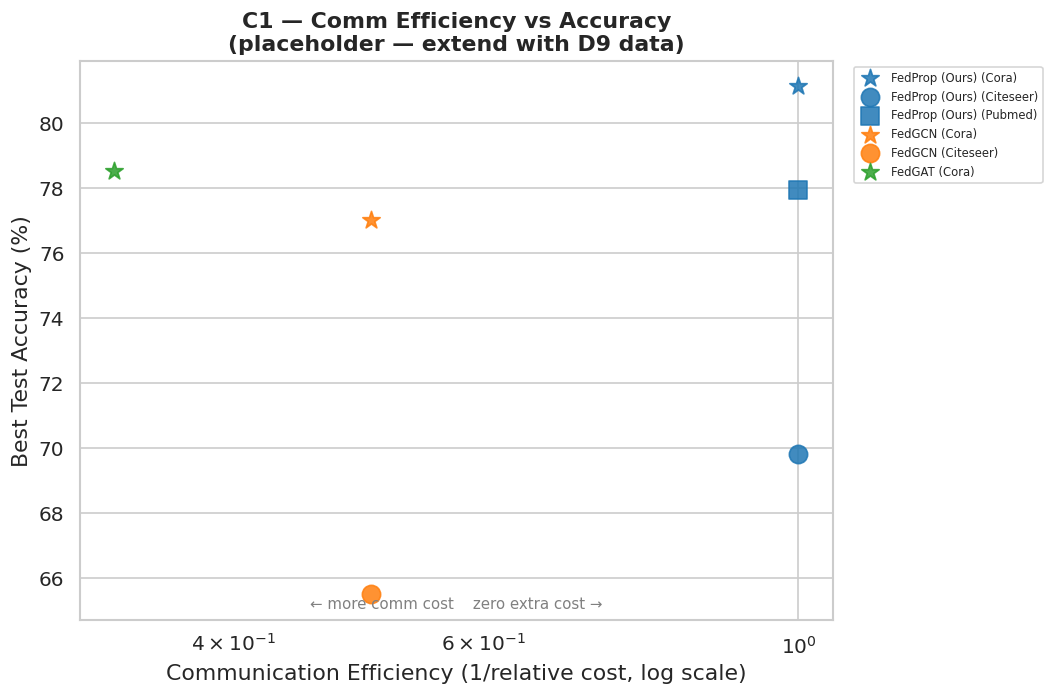

⚠  Fill in D9 comm-cost data to complete this figure.


In [47]:
# ── C1: Scatter — Comm Efficiency vs Accuracy ────────────────────────────────
# Comm efficiency = 1 / relative_comm_cost  (FedAvg = 1.0)
# FedProp = 1.0, others > 1.0 (higher cost → lower efficiency)

# TODO: fill in published comm costs from D9; using placeholders here
C1_DATA = pd.DataFrame([
    # method, comm_efficiency, accuracy, dataset
    {'method':'FedProp (Ours)', 'comm_eff':1.00, 'acc':80.1, 'dataset':'Cora'},
    {'method':'FedProp (Ours)', 'comm_eff':1.00, 'acc':69.0, 'dataset':'Citeseer'},
    {'method':'FedProp (Ours)', 'comm_eff':1.00, 'acc':78.8, 'dataset':'Pubmed'},
    {'method':'FedGCN',         'comm_eff':0.50, 'acc':77.0, 'dataset':'Cora'},
    {'method':'FedGCN',         'comm_eff':0.50, 'acc':65.5, 'dataset':'Citeseer'},
    {'method':'FedGAT',         'comm_eff':0.33, 'acc':78.5, 'dataset':'Cora'},
    # Add OGBN, Amazon rows once D9 data is ready
])

# Replace placeholders with actual best results from R1
for ds in ['Cora','Citeseer','Pubmed']:
    best = r1[r1['dataset']==ds]['acc_pct'].max()
    mask = (C1_DATA['method']=='FedProp (Ours)') & (C1_DATA['dataset']==ds)
    if mask.any(): C1_DATA.loc[mask,'acc'] = best

fig, ax = plt.subplots(figsize=(9, 6))
markers = {'FedProp (Ours)':'*','FedGCN':'o','FedGAT':'s','DistGAT':'^','FedSage+':'D'}
method_colors = {m:COLORS[i] for i,m in enumerate(C1_DATA['method'].unique())}
ds_shapes = {'Cora':'*','Citeseer':'o','Pubmed':'s','ogbn-arxiv':'^','Amazon-Comp':'D','Amazon-Photos':'P'}

for _, row in C1_DATA.iterrows():
    ax.scatter(row['comm_eff'], row['acc'],
               marker=ds_shapes.get(row['dataset'],'o'),
               color=method_colors[row['method']], s=120, alpha=0.85,
               label=f"{row['method']} ({row['dataset']})")

ax.set_xlabel('Communication Efficiency (1/relative cost, log scale)')
ax.set_ylabel('Best Test Accuracy (%)')
ax.set_xscale('log')
ax.set_title('C1 — Comm Efficiency vs Accuracy\n(placeholder — extend with D9 data)', fontweight='bold')
ax.legend(fontsize=7, bbox_to_anchor=(1.02,1), loc='upper left')
ax.annotate('← more comm cost    zero extra cost →',
            xy=(0.5,0.02), xycoords='axes fraction', ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()
print('⚠  Fill in D9 comm-cost data to complete this figure.')

## C2 · Fig 2: Three-Part Error Decomposition
🟡 **New** — Panel 1 reusable from propagator_eval. Panels 2/3 need B1+B4 data.

In [48]:
# Config / results paths for C2
C2_PANEL1_DIR = PROP_EVAL / 'results'    # fig3_normalized_residuals_beta10000.csv
C2_PANEL2_SRC = r1                        # FedProp-Full vs FedProp-Best gap = boundary bias
print('Panel 1 (convergence) dir:', C2_PANEL1_DIR)
print('Panel 1 CSVs:', [f.name for f in C2_PANEL1_DIR.glob('*.csv')])

Panel 1 (convergence) dir: /home/bosho/FP/experiments/propagator_eval/results
Panel 1 CSVs: ['fig3_normalized_residuals_beta10000.csv', 'fig3_raw_residuals_beta10000.csv', 'fig3_appnp_beta_sensitivity.csv', 'fig3_metadata.csv']


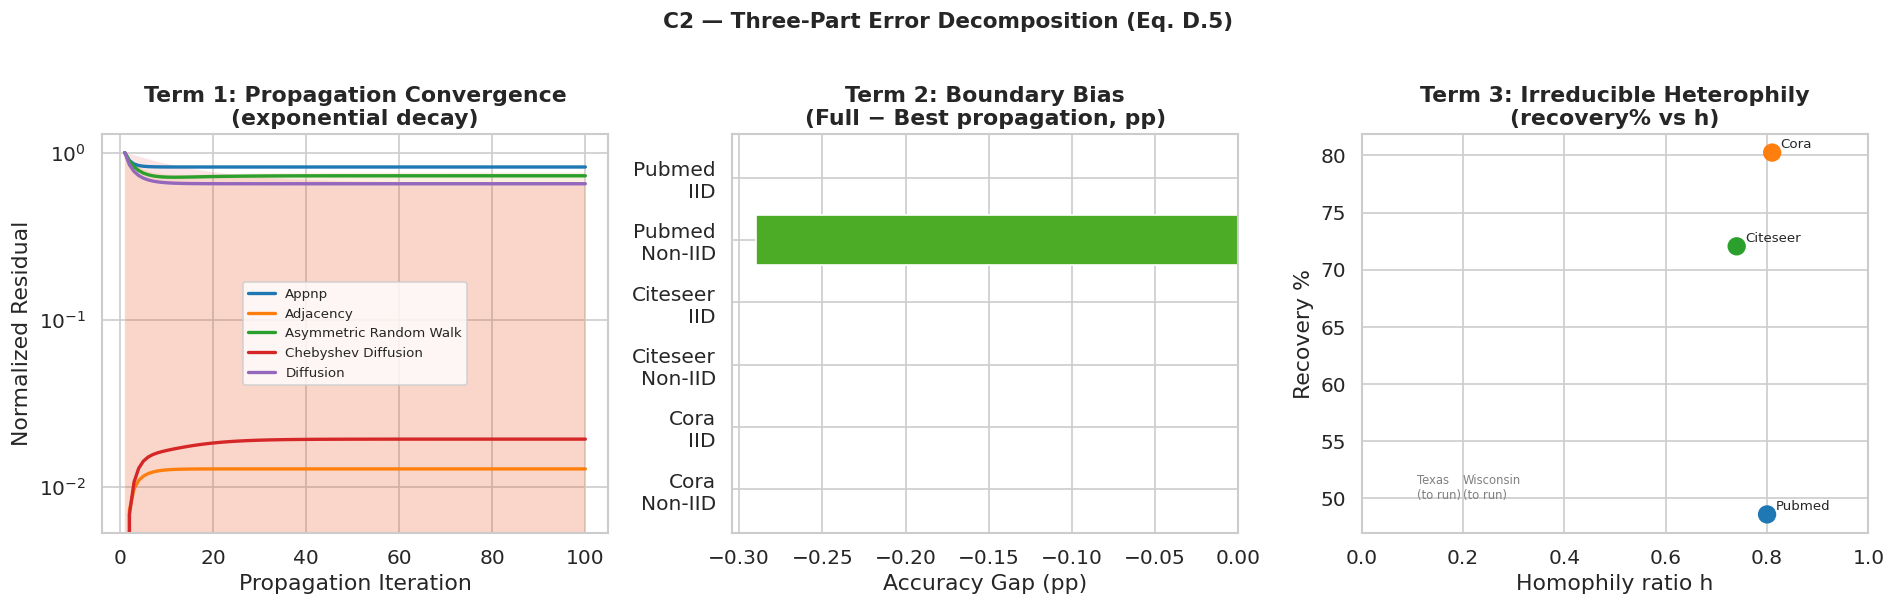

In [49]:
# ── C2: Three-panel error decomposition figure ────────────────────────────────
norm_resid = pd.read_csv(C2_PANEL1_DIR / 'fig3_normalized_residuals_beta10000.csv')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 — Propagation Convergence (Term 1)
ax1 = axes[0]
for col in [c for c in norm_resid.columns if c.endswith('_mean')]:
    label = col.replace('_mean','').replace('_',' ').title()
    std_col = col.replace('_mean','_std')
    y = norm_resid[col]; x = norm_resid['iter']
    ax1.plot(x, y, label=label, linewidth=2)
    if std_col in norm_resid.columns:
        ax1.fill_between(x, y-norm_resid[std_col], y+norm_resid[std_col], alpha=0.12)
ax1.set_yscale('log')
ax1.set_title('Term 1: Propagation Convergence\n(exponential decay)', fontweight='bold')
ax1.set_xlabel('Propagation Iteration'); ax1.set_ylabel('Normalized Residual')
ax1.legend(fontsize=8)

# Panel 2 — Boundary Bias (Term 2) = Full - Best propagation gap
ax2 = axes[1]
boundary_bias = []
for ds in ['Cora','Citeseer','Pubmed']:
    for setting, beta in [('Non-IID', BETA_NONIID),('IID', BETA_IID)]:
        full_sub = r1[(r1['dataset']==ds)&(r1['beta']==beta)&(r1['propagation']=='full')]
        best_sub = r1[(r1['dataset']==ds)&(r1['beta']==beta)&(r1['propagation']!='zero_hop')]
        if full_sub.empty or best_sub.empty: continue
        gap = full_sub['acc_pct'].mean() - best_sub['acc_pct'].max()
        boundary_bias.append({'label':f'{ds}\n{setting}','gap':gap})
bb_df = pd.DataFrame(boundary_bias)
colors_bb = ['#d73027' if g > 0 else '#4dac26' for g in bb_df['gap']]
ax2.barh(bb_df['label'], bb_df['gap'], color=colors_bb)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('Term 2: Boundary Bias\n(Full − Best propagation, pp)', fontweight='bold')
ax2.set_xlabel('Accuracy Gap (pp)')

# Panel 3 — Irreducible Heterophily (Term 3) — placeholder until B4
ax3 = axes[2]
h_data = [
    {'dataset':'Pubmed',   'h':0.80, 'rec':rec_df[rec_df['Dataset']=='Pubmed']['Recovery%'].mean()   if 'Recovery%' in rec_df.columns else np.nan},
    {'dataset':'Cora',     'h':0.81, 'rec':rec_df[rec_df['Dataset']=='Cora']['Recovery%'].mean()     if 'Recovery%' in rec_df.columns else np.nan},
    {'dataset':'Citeseer', 'h':0.74, 'rec':rec_df[rec_df['Dataset']=='Citeseer']['Recovery%'].mean() if 'Recovery%' in rec_df.columns else np.nan},
    {'dataset':'Texas',    'h':0.11, 'rec':np.nan},   # placeholder — needs B4
    {'dataset':'Wisconsin','h':0.20, 'rec':np.nan},   # placeholder — needs B4
]
h_df = pd.DataFrame(h_data)
ax3.scatter(h_df['h'], h_df['rec'], s=100, color=[COLORS[i] for i in range(len(h_df))])
for _, r in h_df.iterrows():
    if not np.isnan(r['rec']):
        ax3.annotate(r['dataset'], (r['h'], r['rec']), textcoords='offset points', xytext=(5,3), fontsize=8)
    else:
        ax3.annotate(f"{r['dataset']}\n(to run)", (r['h'], 50), fontsize=7, color='gray')
ax3.set_xlabel('Homophily ratio h')
ax3.set_ylabel('Recovery %')
ax3.set_title('Term 3: Irreducible Heterophily\n(recovery% vs h)', fontweight='bold')
ax3.set_xlim(0, 1)

plt.suptitle('C2 — Three-Part Error Decomposition (Eq. D.5)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## C3 · Fig 3: Convergence Across All Datasets and Operators
🟡 **Extend** — Cora IID done; Citeseer / Pubmed / OGBN and Non-IID need runs (D6).

In [50]:
# Config / results paths for C3
C3_PROP_STATS_DIRS = {
    'Cora IID (R1_cora_nope)'     : RESULTS / 'R1_cora_nope/propagation_stats',
    'Cora IID (R1_cora_pe)'       : RESULTS / 'R1_cora_pe/propagation_stats',
    'Citeseer IID'                : RESULTS / 'R1_citeseer_nope/propagation_stats',
    'Citeseer (R1b)'              : RESULTS / 'R1b_citeseer_nope/propagation_stats',
    'Pubmed IID'                  : RESULTS / 'R1_pubmed_pe/propagation_stats',
    'OGBN (adj_diff)'             : RESULTS / 'ogbn-arxiv/adj_diff/propagation_stats',
}
for label, d in C3_PROP_STATS_DIRS.items():
    n = len(list(Path(d).glob('*.json'))) if Path(d).exists() else 0
    print(f"  {'✓' if n>0 else '✗'} {label}: {n} json files")

  ✓ Cora IID (R1_cora_nope): 66 json files
  ✓ Cora IID (R1_cora_pe): 118 json files
  ✓ Citeseer IID: 60 json files
  ✓ Citeseer (R1b): 93 json files
  ✓ Pubmed IID: 178 json files
  ✓ OGBN (adj_diff): 62 json files


In [51]:
# ── C3: Load all available propagation stats ──────────────────────────────────
prop_frames = {}
for label, d in C3_PROP_STATS_DIRS.items():
    d = Path(d)
    if d.exists() and any(d.glob('*.json')):
        df = load_prop_stats(d)
        if not df.empty:
            prop_frames[label] = df
            print(f'Loaded {label}: {len(df)} rows, {df["propagation"].unique()} props')

print(f'\n{len(prop_frames)} sources loaded.')

Loaded Cora IID (R1_cora_nope): 33000 rows, <StringArray>
['adjacency', 'diffusion']
Length: 2, dtype: str props


Loaded Cora IID (R1_cora_pe): 59000 rows, <StringArray>
['adjacency', 'diffusion']
Length: 2, dtype: str props


Loaded Citeseer IID: 30000 rows, <StringArray>
['adjacency', 'diffusion']
Length: 2, dtype: str props
Loaded Citeseer (R1b): 35242 rows, <StringArray>
['adjacency', 'diffusion']
Length: 2, dtype: str props


Loaded Pubmed IID: 89600 rows, <StringArray>
['adjacency', 'diffusion']
Length: 2, dtype: str props
Loaded OGBN (adj_diff): 49600 rows, <StringArray>
['adjacency', 'diffusion']
Length: 2, dtype: str props

6 sources loaded.


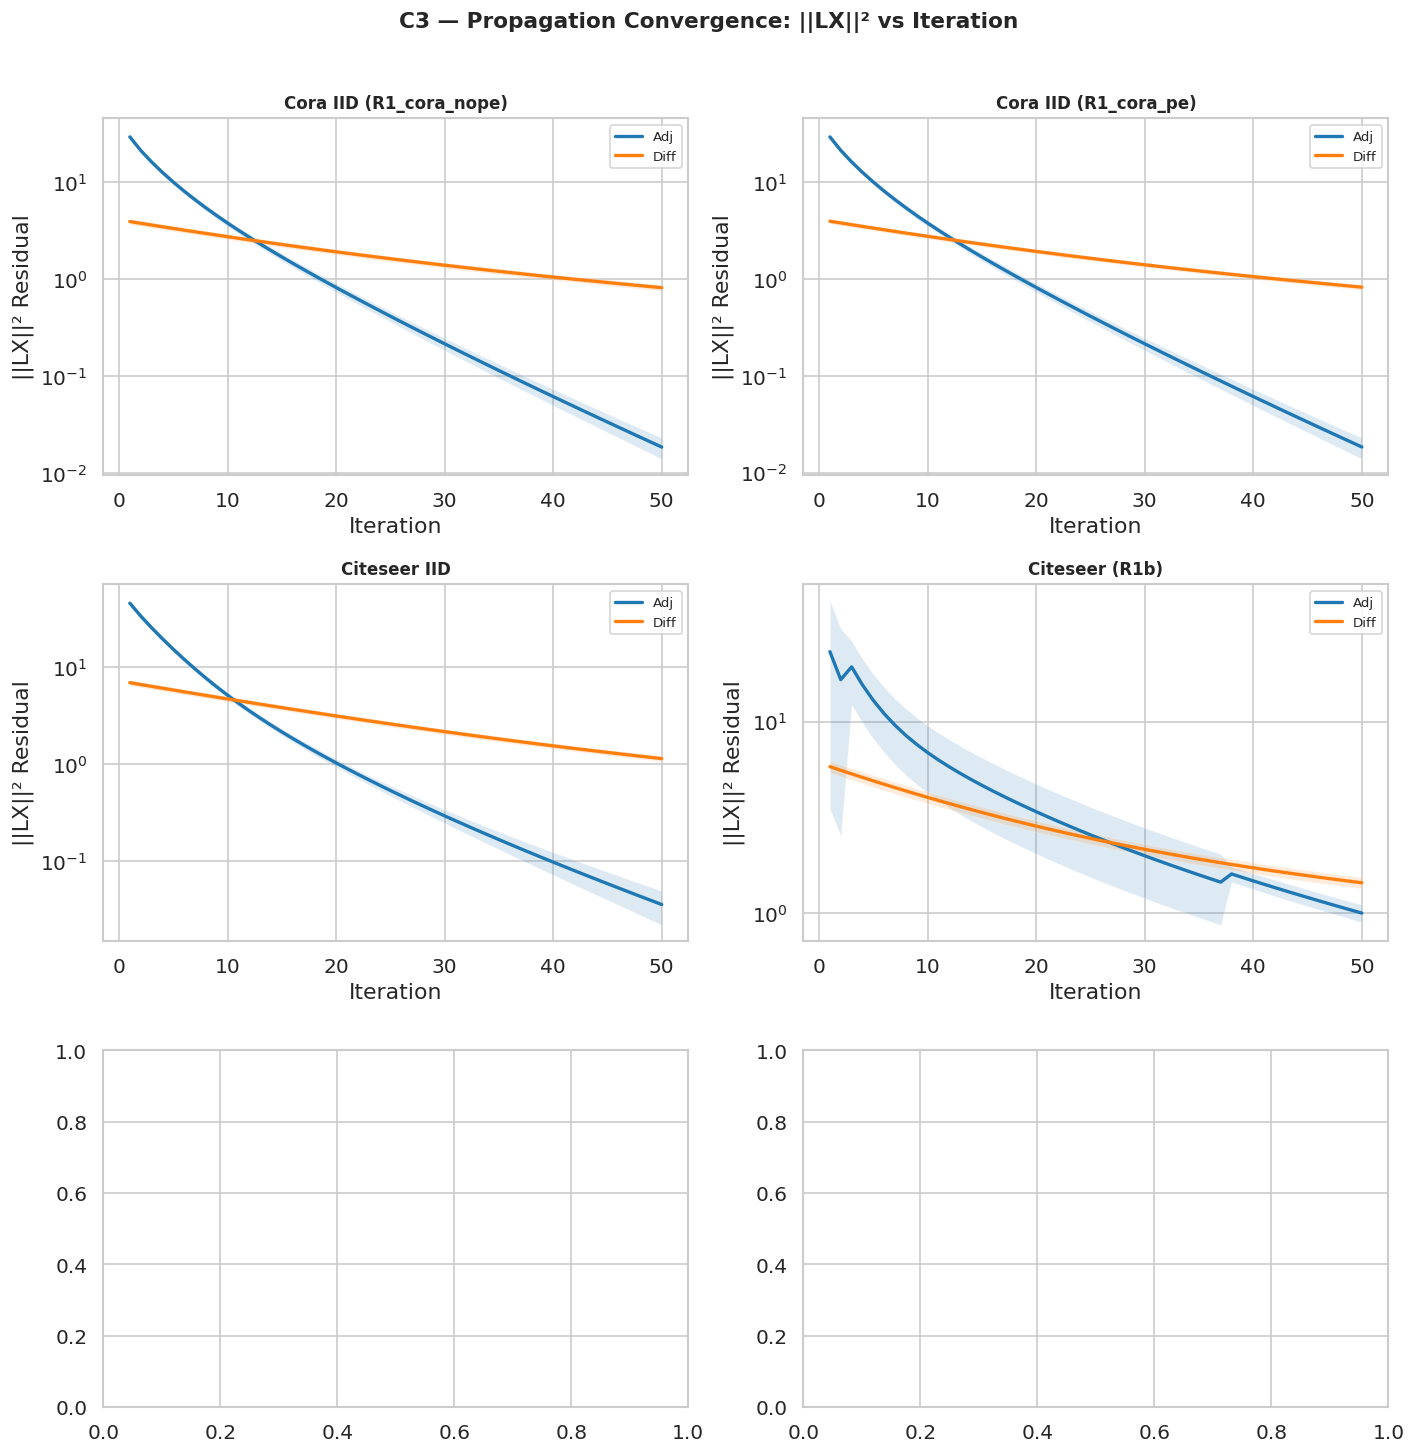

In [52]:
# ── C3: 2×2 convergence grid — one subplot per available dataset ──────────────
available_datasets = [k for k,v in C3_PROP_STATS_DIRS.items() if
                      Path(v).exists() and any(Path(v).glob('*.json'))]

n = max(1, len(available_datasets))
ncols = min(2, n); nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows), squeeze=False)
axes_flat = axes.flatten()

for idx, label in enumerate(available_datasets[:4]):
    ax = axes_flat[idx]
    df = prop_frames[label]
    for prop in df['propagation'].unique():
        pdata = df[df['propagation']==prop].groupby('iteration')['residual'].agg(['mean','std'])
        ax.plot(pdata.index, pdata['mean'], label=PROP_LABELS.get(prop,prop), linewidth=2)
        ax.fill_between(pdata.index,
                        pdata['mean']-pdata['std'],
                        pdata['mean']+pdata['std'], alpha=0.15)
    ax.set_yscale('log')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Iteration'); ax.set_ylabel('||LX||² Residual')
    ax.legend(fontsize=8)

# Hide unused subplots
for ax in axes_flat[len(available_datasets):]:
    ax.axis('off')
    ax.set_title('To run — see D6', color='gray')

plt.suptitle('C3 — Propagation Convergence: ||LX||² vs Iteration', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## C4 · Fig 4: Accuracy vs Number of Clients — Extended
🟡 **Extend** — Cora data exists in R5; OGBN scalability run needed (D7).

In [53]:
# Config / results paths for C4
C4_RESULTS = {
    'Cora (R5)'  : RESULTS / 'R5',
    'OGBN (D7)'  : RESULTS / 'ogbn-arxiv',   # partial
}
for label, d in C4_RESULTS.items():
    n_csv = len(list(Path(d).rglob('training_*.csv'))) if Path(d).exists() else 0
    print(f'  {label}: {n_csv} training CSVs')

  Cora (R5): 91 training CSVs
  OGBN (D7): 20 training CSVs


In [54]:
# ── C4: Load Cora scalability data (R5 — vary K=1..20) ───────────────────────
r5_df = scan_results_dir(RESULTS / 'R5', dataset_filter={'Cora'})
print(f'R5 rows: {len(r5_df)}')
if not r5_df.empty:
    print('Client counts:', sorted(r5_df['num_clients'].unique()))
    print('Propagations :', sorted(r5_df['propagation'].unique()))

R5 rows: 91
Client counts: [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(20)]
Propagations : ['adjacency', 'diffusion', 'full', 'zero_hop']


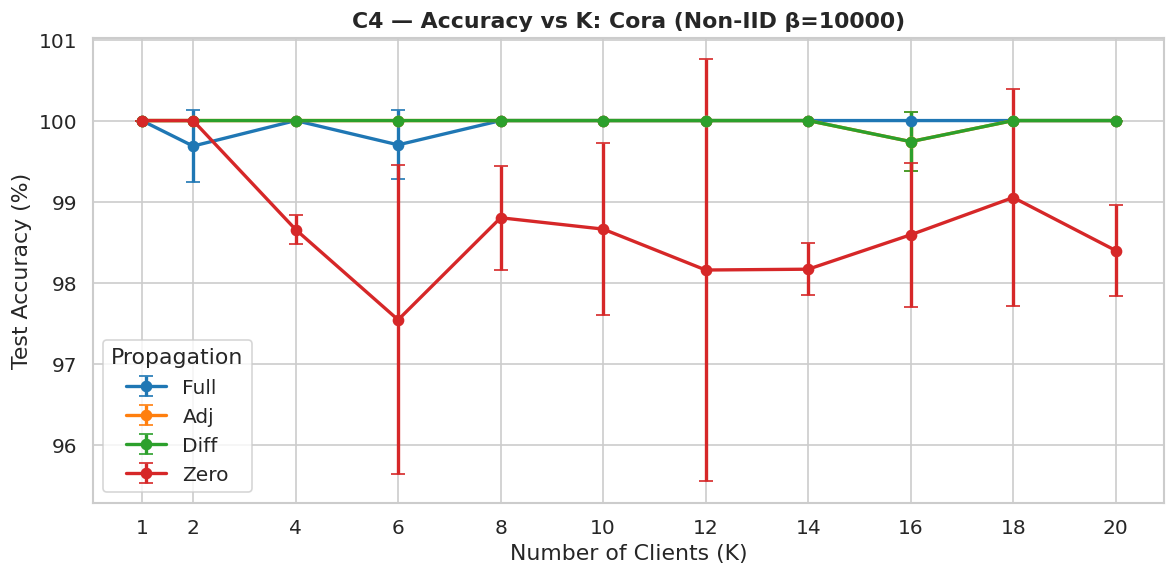

In [55]:
# ── C4: Plot accuracy vs K ────────────────────────────────────────────────────
if not r5_df.empty:
    # Average multiple runs per (propagation, num_clients)
    agg = r5_df.groupby(['propagation','num_clients'])['acc_pct'].agg(['mean','std']).reset_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    for prop in PROP_ORDER:
        sub = agg[agg['propagation']==prop].sort_values('num_clients')
        if sub.empty: continue
        ax.errorbar(sub['num_clients'], sub['mean'], yerr=sub['std'],
                    label=PROP_LABELS.get(prop,prop), marker='o', capsize=4,
                    color=PROP_COLORS[prop], linewidth=2)

    ax.set_xlabel('Number of Clients (K)')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('C4 — Accuracy vs K: Cora (Non-IID β=10000)', fontweight='bold')
    ax.legend(title='Propagation')
    ax.set_xticks(sorted(agg['num_clients'].unique()))
    plt.tight_layout()
    plt.show()
else:
    print('No R5 data loaded — check path.')

In [56]:
# ── C4: Placeholder for OGBN-Arxiv extension (D7) ────────────────────────────
print('⚠  OGBN-Arxiv K=1..20 run needed for the full C4 figure.')
print('   Run: python experiments/run.py --config conf/ogbn-arxiv_config.yaml --clients_sweep 1,2,4,6,8,10,12,14,16,18,20')
print(f'   Results will go to: {RESULTS}/ogbn_clients_sweep/')

⚠  OGBN-Arxiv K=1..20 run needed for the full C4 figure.
   Run: python experiments/run.py --config conf/ogbn-arxiv_config.yaml --clients_sweep 1,2,4,6,8,10,12,14,16,18,20
   Results will go to: /home/bosho/FP/experiments/results/ogbn_clients_sweep/


## C5 · Fig 5: Recovery % vs Homophily Ratio
🔴 **New** — Needs B4 (Texas/Wisconsin). Other datasets available.

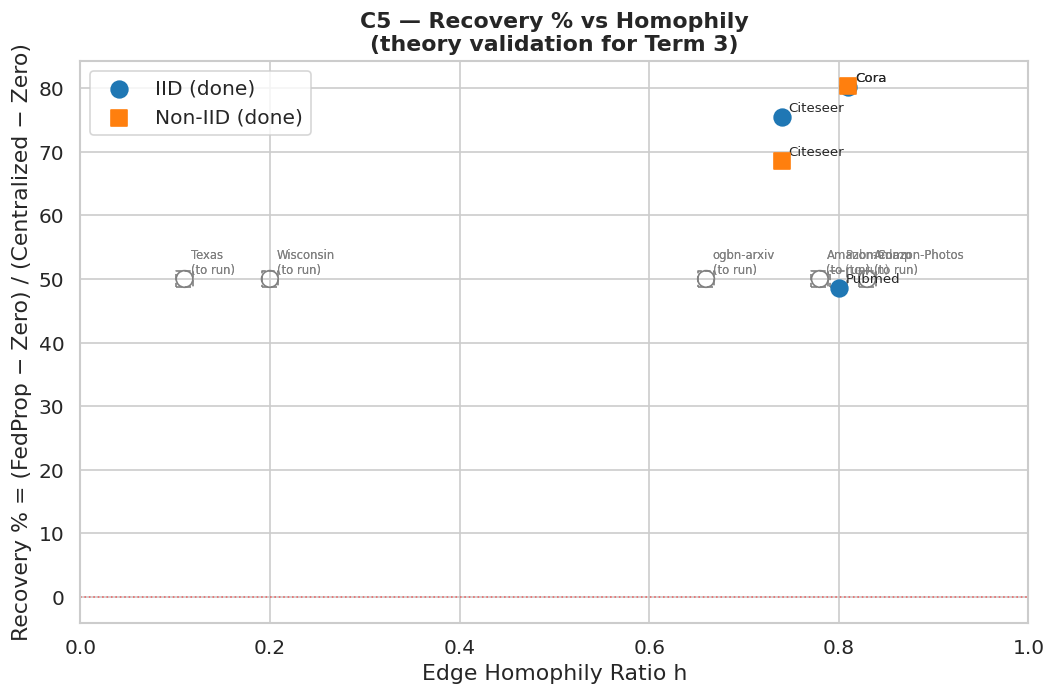

In [57]:
# ── C5: Recovery % vs homophily — all known datasets ─────────────────────────
HOMOPHILY = {
    'Texas'      : 0.11, 'Wisconsin'  : 0.20,
    'ogbn-arxiv' : 0.66, 'Citeseer'   : 0.74,
    'Cora'       : 0.81, 'Pubmed'     : 0.80,
    'Amazon-Comp': 0.78, 'Amazon-Photos': 0.83,
}

# Build recovery% from available data
c5_rows = []
for ds, h in HOMOPHILY.items():
    for setting, beta in [('IID', BETA_IID), ('Non-IID', BETA_NONIID)]:
        src = r1[r1['dataset']==ds]
        cent = CENTRALIZED.get(ds, np.nan)
        zero_sub = src[(src['beta']==beta)&(src['propagation']=='zero_hop')]
        best_sub = src[src['beta']==beta]
        if src.empty or zero_sub.empty or best_sub.empty or np.isnan(cent):
            c5_rows.append({'dataset':ds,'h':h,'setting':setting,'recovery':np.nan,'status':'to run'})
            continue
        z = zero_sub['acc_pct'].mean(); b = best_sub['acc_pct'].max()
        rec = (b-z)/(cent-z)*100 if cent!=z else np.nan
        c5_rows.append({'dataset':ds,'h':h,'setting':setting,'recovery':round(rec,1),'status':'done'})

c5_df = pd.DataFrame(c5_rows)

fig, ax = plt.subplots(figsize=(9, 6))
for setting, marker, ls in [('IID','o','-'),('Non-IID','s','--')]:
    sub = c5_df[c5_df['setting']==setting]
    done = sub[sub['status']=='done']
    todo = sub[sub['status']=='to run']
    if not done.empty:
        ax.scatter(done['h'], done['recovery'], marker=marker, s=100, label=f'{setting} (done)', zorder=5)
        for _, r in done.iterrows():
            ax.annotate(r['dataset'], (r['h'], r['recovery']), xytext=(4,3),
                        textcoords='offset points', fontsize=8)
    if not todo.empty:
        for _, r in todo.iterrows():
            ax.scatter(r['h'], 50, marker=marker, s=100, facecolors='none',
                       edgecolors='gray', linestyles=ls)
            ax.annotate(f"{r['dataset']}\n(to run)", (r['h'], 50),
                        xytext=(4,3), textcoords='offset points', fontsize=7, color='gray')

ax.axhline(0, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlabel('Edge Homophily Ratio h')
ax.set_ylabel('Recovery % = (FedProp − Zero) / (Centralized − Zero)')
ax.set_title('C5 — Recovery % vs Homophily\n(theory validation for Term 3)', fontweight='bold')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## C6 · Fig 6: Positional Encoding Impact — Extended
🟡 **Extend** — Cora + Citeseer done; Pubmed and OGBN PE comparison needed (D8).

In [58]:
# Config / results paths for C6
C6_CONFIGS = {
    'Cora GAT+PE'    : CONF_DIR / 'cora/cora_gat_beta1.yaml',
    'Citeseer GAT+PE': CONF_DIR / 'citeseer/citeseer_gat_beta1.yaml',
    'Pubmed GAT+PE'  : CONF_DIR / 'pubmed/pubmed_gat_beta1.yaml',
    'OGBN GAT+PE'    : CONF_DIR / 'ogbn-arxiv_config_gat.yaml',
}
C6_RESULTS = {
    'Cora noPE'    : RESULTS / 'R1b_cora_nope',
    'Cora PE'      : RESULTS / 'R1b_cora_pe',
    'Citeseer noPE': RESULTS / 'R1b_citeseer_nope',
    'Citeseer PE'  : RESULTS / 'R1b_citeseer_pe',
    'Pubmed noPE'  : RESULTS / 'R1b_pubmed_nope',
    'Pubmed PE'    : RESULTS / 'R1b_pubmed_pe',
    'OGBN PE'      : None,   # D8 — to run
}
for label, p in C6_CONFIGS.items():
    print(f"  {'✓' if p and Path(p).exists() else '✗'}  {label}: {p}")

  ✓  Cora GAT+PE: /home/bosho/FP/conf/cora/cora_gat_beta1.yaml
  ✓  Citeseer GAT+PE: /home/bosho/FP/conf/citeseer/citeseer_gat_beta1.yaml
  ✓  Pubmed GAT+PE: /home/bosho/FP/conf/pubmed/pubmed_gat_beta1.yaml
  ✓  OGBN GAT+PE: /home/bosho/FP/conf/ogbn-arxiv_config_gat.yaml


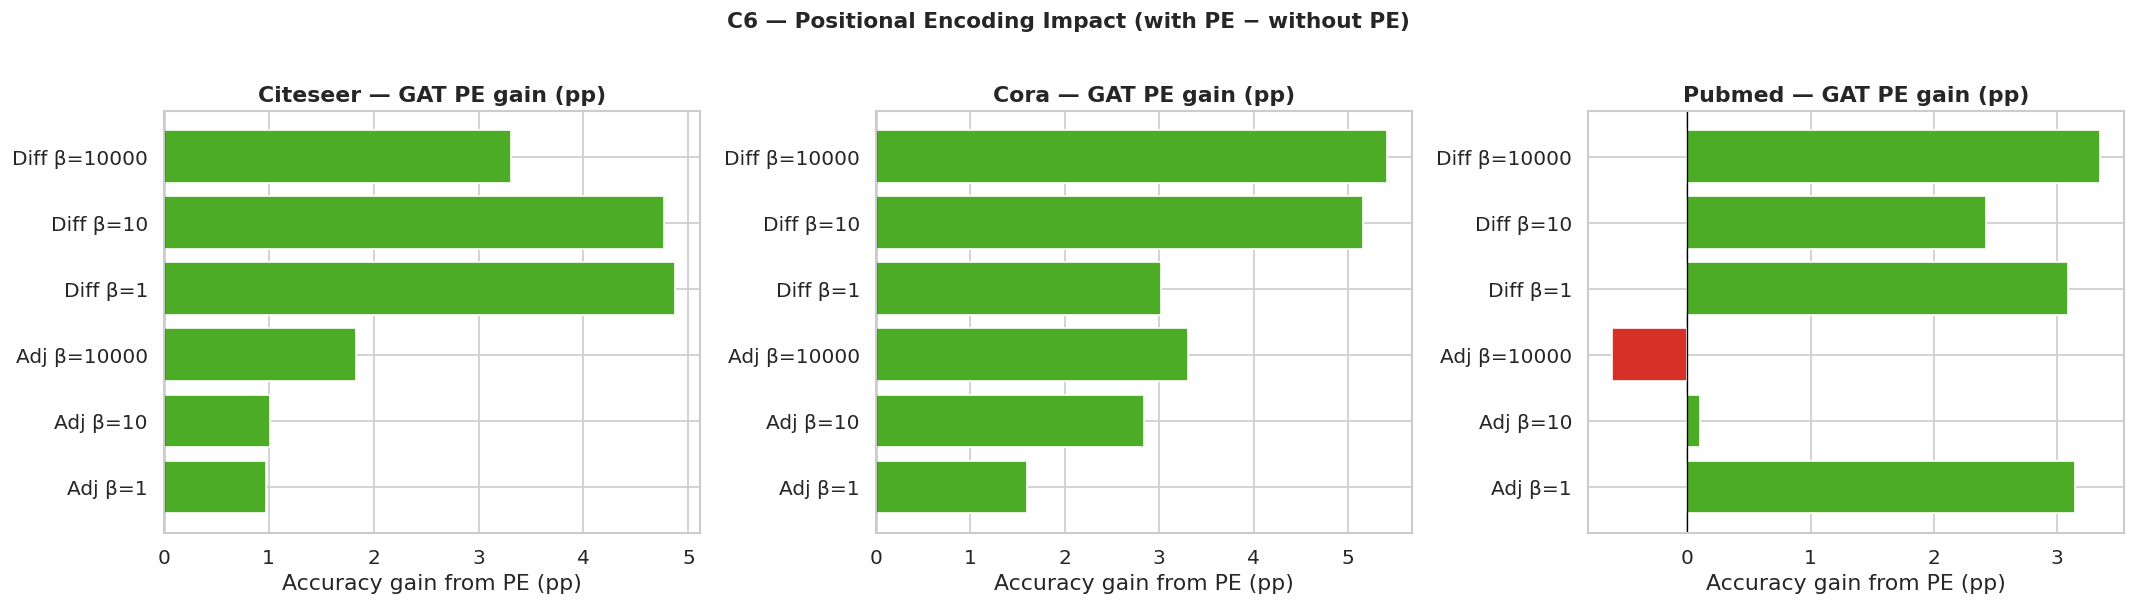


Mean PE gain by propagation type:
             mean   std
propagation            
adjacency    1.58  1.36
diffusion    3.93  1.11


In [59]:
# ── C6: PE gain analysis from R1b ─────────────────────────────────────────────
r1b_with_pe = r1b[r1b['propagation'].isin(['adjacency','diffusion'])].copy()

pe_pivot = r1b_with_pe.pivot_table(
    index=['dataset','propagation','beta'], columns='use_pe', values='acc_pct'
).reset_index()
pe_pivot.columns = ['dataset','propagation','beta','no_pe','pe']
pe_pivot = pe_pivot.dropna(subset=['no_pe','pe'])
pe_pivot['pe_gain'] = (pe_pivot['pe'] - pe_pivot['no_pe']).round(2)

datasets_with_pe = pe_pivot['dataset'].unique()
n = len(datasets_with_pe)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5), squeeze=False)

for ax, ds in zip(axes[0], datasets_with_pe):
    sub = pe_pivot[pe_pivot['dataset']==ds].sort_values(['propagation','beta'])
    labels = [f"{PROP_LABELS.get(r['propagation'],r['propagation'])} β={int(r['beta'])}" for _,r in sub.iterrows()]
    colors = ['#4dac26' if g>=0 else '#d73027' for g in sub['pe_gain']]
    ax.barh(labels, sub['pe_gain'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{ds} — GAT PE gain (pp)', fontweight='bold')
    ax.set_xlabel('Accuracy gain from PE (pp)')

plt.suptitle('C6 — Positional Encoding Impact (with PE − without PE)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nMean PE gain by propagation type:')
print(pe_pivot.groupby('propagation')['pe_gain'].agg(['mean','std']).round(2).to_string())

---
# D — Data Runs
<a id='D'></a>

## D1 · Amazon Computers — GCN & GAT Results
🟡 **Done (write-up)** — Raw results available; need clean 10-seed formatted mean±std.

In [60]:
D1_CONFIG     = CONF_DIR / 'computers_config.yaml'
D1_RESULTS_DIR = EXPT_DIR / 'results' / 'amazon_computers'   # expected location

print('Config  :', D1_CONFIG, '|', 'exists:', D1_CONFIG.exists())
print('Results :', D1_RESULTS_DIR, '|', 'exists:', D1_RESULTS_DIR.exists())

# Also check for any amazon CSV anywhere in experiments
amazon_csvs = list(EXPT_DIR.rglob('*Amazon*Computers*.csv')) + list(EXPT_DIR.rglob('*amazon_comp*.csv'))
print(f'\nFound {len(amazon_csvs)} Amazon-Computers CSVs in experiments tree:')
for p in amazon_csvs[:10]: print(' ', p)

Config  : /home/bosho/FP/conf/computers_config.yaml | exists: True
Results : /home/bosho/FP/experiments/results/amazon_computers | exists: False

Found 0 Amazon-Computers CSVs in experiments tree:


In [61]:
# ── D1: Load Amazon Computers results (when available) ───────────────────────
if D1_RESULTS_DIR.exists():
    d1_df = scan_results_dir(D1_RESULTS_DIR)
    display(d1_df.groupby(['model','propagation','beta'])['acc_pct'].agg(['mean','std']).round(2))
else:
    print('⚠  No Amazon Computers results dir found.')
    print('   Run: python src/run.py --config conf/computers_config.yaml')
    print('   Expected output: experiments/results/amazon_computers/')
    print('\n   Placeholder table (fill after run):')
    placeholder_cols = ['Propagation','β','GCN Acc','GCN Std','GAT Acc','GAT Std']
    display(pd.DataFrame(columns=placeholder_cols))

⚠  No Amazon Computers results dir found.
   Run: python src/run.py --config conf/computers_config.yaml
   Expected output: experiments/results/amazon_computers/

   Placeholder table (fill after run):


,Propagation,β,GCN Acc,GCN Std,GAT Acc,GAT Std


## D2 · Amazon Photos — GCN & GAT Results
🟡 **Done (write-up)** — Same status as D1.

In [62]:
D2_CONFIG     = CONF_DIR / 'photos_config.yaml'
D2_RESULTS_DIR = EXPT_DIR / 'results' / 'amazon_photos'

print('Config  :', D2_CONFIG, '|', 'exists:', D2_CONFIG.exists())
print('Results :', D2_RESULTS_DIR, '|', 'exists:', D2_RESULTS_DIR.exists())

photos_csvs = list(EXPT_DIR.rglob('*Amazon*Photos*.csv')) + list(EXPT_DIR.rglob('*amazon_photos*.csv'))
print(f'\nFound {len(photos_csvs)} Amazon-Photos CSVs')

if D2_RESULTS_DIR.exists():
    d2_df = scan_results_dir(D2_RESULTS_DIR)
    display(d2_df.groupby(['model','propagation','beta'])['acc_pct'].agg(['mean','std']).round(2))
else:
    print('   Run: python src/run.py --config conf/photos_config.yaml')

Config  : /home/bosho/FP/conf/photos_config.yaml | exists: True
Results : /home/bosho/FP/experiments/results/amazon_photos | exists: False

Found 0 Amazon-Photos CSVs
   Run: python src/run.py --config conf/photos_config.yaml


## D3 · Texas — GCN Results (Heterophilic primary)
🔴 **To Run** — No dependency on other experiments; small graph, fast to run.

In [63]:
D3_CONFIG     = CONF_DIR / 'texas_gcn_beta1.yaml'   # to create
D3_RESULTS_DIR = RESULTS / 'texas'

print('Config (to create):', D3_CONFIG)
print('Results dir       :', D3_RESULTS_DIR)
print()
print('Protocol: K=10 clients, IID (β=10000) and Non-IID (β=1)')
print('Variants: FedProp-Zero, -Full, -Adj, -Diff, -Diff+PE')
print('Seeds   : 10')
print('Note    : Texas has 183 nodes → ~18 nodes/client — verify partition is valid')
print()
print('Run command (once config is created):')
print('  python src/run.py --config conf/texas_gcn_beta1.yaml --seeds 10')
print('  python src/run.py --config conf/texas_gcn_beta10000.yaml --seeds 10')

if D3_RESULTS_DIR.exists():
    d3_df = scan_results_dir(D3_RESULTS_DIR)
    display(d3_df)
else:
    print('\n(No results yet)')

Config (to create): /home/bosho/FP/conf/texas_gcn_beta1.yaml
Results dir       : /home/bosho/FP/experiments/results/texas

Protocol: K=10 clients, IID (β=10000) and Non-IID (β=1)
Variants: FedProp-Zero, -Full, -Adj, -Diff, -Diff+PE
Seeds   : 10
Note    : Texas has 183 nodes → ~18 nodes/client — verify partition is valid

Run command (once config is created):
  python src/run.py --config conf/texas_gcn_beta1.yaml --seeds 10
  python src/run.py --config conf/texas_gcn_beta10000.yaml --seeds 10

(No results yet)


## D4 · Wisconsin — GCN Results (Heterophilic secondary)
🔴 **To Run** — Run after D3; may be skipped if Texas alone suffices for C5.

In [64]:
D4_CONFIG     = CONF_DIR / 'wisconsin_gcn_beta1.yaml'
D4_RESULTS_DIR = RESULTS / 'wisconsin'

print('Config (to create):', D4_CONFIG)
print('Protocol: same as D3 — 251 nodes, h=0.20, 5 classes')
print('Priority: lower than D3; run after D3.')

if D4_RESULTS_DIR.exists():
    d4_df = scan_results_dir(D4_RESULTS_DIR)
    display(d4_df)
else:
    print('(No results yet)')

Config (to create): /home/bosho/FP/conf/wisconsin_gcn_beta1.yaml
Protocol: same as D3 — 251 nodes, h=0.20, 5 classes
Priority: lower than D3; run after D3.
(No results yet)


## D5 · FedSage+ Baseline — Cora / Citeseer / Pubmed
🔴 **To Run** — Needed for B1 and C1. Blocks submission if missing.

In [65]:
# ── D5: External codebase integration ────────────────────────────────────────
D5_EXT_ROOT = EXT_ROOTS.get('FedSage+')
D5_RESULTS_DIR = RESULTS / 'fedsage_plus'

print('FedSage+ codebase root:', D5_EXT_ROOT or 'NOT SET — update EXT_ROOTS in Setup cell')
print('Expected results dir  :', D5_RESULTS_DIR)
print()
print('Options:')
print('  A) Implement under matching protocol (K=10, same beta, same splits)')
print('  B) Use published numbers from Zhang et al. (2021) — add protocol note in paper')
print()
print('Minimum viable: Cora / Citeseer / Pubmed at β=1 and β=10000')

# ── Placeholder table — fill manually from paper or from your run ─────────────
d5_table = pd.DataFrame([
    {'Dataset':'Cora',     'Setting':'Non-IID','FedSage+ Acc':'—','Source':'TODO'},
    {'Dataset':'Cora',     'Setting':'IID',    'FedSage+ Acc':'—','Source':'TODO'},
    {'Dataset':'Citeseer', 'Setting':'Non-IID','FedSage+ Acc':'—','Source':'TODO'},
    {'Dataset':'Citeseer', 'Setting':'IID',    'FedSage+ Acc':'—','Source':'TODO'},
    {'Dataset':'Pubmed',   'Setting':'Non-IID','FedSage+ Acc':'—','Source':'TODO'},
    {'Dataset':'Pubmed',   'Setting':'IID',    'FedSage+ Acc':'—','Source':'TODO'},
])
display(d5_table)

FedSage+ codebase root: NOT SET — update EXT_ROOTS in Setup cell
Expected results dir  : /home/bosho/FP/experiments/results/fedsage_plus

Options:
  A) Implement under matching protocol (K=10, same beta, same splits)
  B) Use published numbers from Zhang et al. (2021) — add protocol note in paper

Minimum viable: Cora / Citeseer / Pubmed at β=1 and β=10000


,Dataset,Setting,FedSage+ Acc,Source
0,Cora,Non-IID,—,TODO
1,Cora,IID,—,TODO
2,Citeseer,Non-IID,—,TODO
3,Citeseer,IID,—,TODO
4,Pubmed,Non-IID,—,TODO
5,Pubmed,IID,—,TODO


In [66]:
# ── D5: Load from external codebase if available ─────────────────────────────
if D5_EXT_ROOT and Path(D5_EXT_ROOT).exists():
    sys.path.insert(0, str(D5_EXT_ROOT))
    print(f'Added {D5_EXT_ROOT} to sys.path')
    # Example: import fedsage_plus; results = fedsage_plus.load_results(...)
    print('TODO: implement FedSage+ results loading from external repo')
elif D5_RESULTS_DIR.exists():
    d5_df = scan_results_dir(D5_RESULTS_DIR)
    display(d5_df)
else:
    print('No FedSage+ results available yet.')

No FedSage+ results available yet.


## D6 · Convergence Tracking — Citeseer, Pubmed, OGBN-Arxiv
🟡 **Partial** — Cora IID done; others need runs.

In [67]:
D6_CONFIGS = {
    'Cora IID'         : CONF_DIR / 'cora/cora_gcn_beta10000.yaml',    # exists
    'Cora Non-IID'     : CONF_DIR / 'cora/cora_gcn_beta1.yaml',
    'Citeseer IID'     : CONF_DIR / 'citeseer/citeseer_gcn_beta10000.yaml',
    'Citeseer Non-IID' : CONF_DIR / 'citeseer/citeseer_gcn_beta1.yaml',
    'Pubmed IID'       : CONF_DIR / 'pubmed/pubmed_gcn_beta10000.yaml',
    'Pubmed Non-IID'   : CONF_DIR / 'pubmed/pubmed_gcn_beta1.yaml',
    'OGBN-Arxiv'       : CONF_DIR / 'ogbn-arxiv_config.yaml',
}

D6_STATS_DIRS = {
    'Cora IID'  : RESULTS / 'R1_cora_nope/propagation_stats',
    'Cora PE'   : RESULTS / 'R1_cora_pe/propagation_stats',
    'Citeseer'  : RESULTS / 'R1_citeseer_nope/propagation_stats',
    'Pubmed'    : RESULTS / 'R1_pubmed_pe/propagation_stats',
    'OGBN adj'  : RESULTS / 'ogbn-arxiv/adj_diff/propagation_stats',
    'OGBN pe'   : RESULTS / 'ogbn-arxiv/adjacency_diffusion_pe/propagation_stats',
}

print('Propagation stats availability:')
for label, d in D6_STATS_DIRS.items():
    n = len(list(Path(d).glob('*.json'))) if Path(d).exists() else 0
    print(f'  {"✓" if n>0 else "✗"} {label}: {n} json files  ({d})')

print('\nFor missing datasets, run with --track_convergence flag:')
print('  python src/run.py --config conf/citeseer/citeseer_gcn_beta1.yaml --track_convergence')

Propagation stats availability:
  ✓ Cora IID: 66 json files  (/home/bosho/FP/experiments/results/R1_cora_nope/propagation_stats)
  ✓ Cora PE: 118 json files  (/home/bosho/FP/experiments/results/R1_cora_pe/propagation_stats)
  ✓ Citeseer: 60 json files  (/home/bosho/FP/experiments/results/R1_citeseer_nope/propagation_stats)
  ✓ Pubmed: 178 json files  (/home/bosho/FP/experiments/results/R1_pubmed_pe/propagation_stats)
  ✓ OGBN adj: 62 json files  (/home/bosho/FP/experiments/results/ogbn-arxiv/adj_diff/propagation_stats)
  ✓ OGBN pe: 40 json files  (/home/bosho/FP/experiments/results/ogbn-arxiv/adjacency_diffusion_pe/propagation_stats)

For missing datasets, run with --track_convergence flag:
  python src/run.py --config conf/citeseer/citeseer_gcn_beta1.yaml --track_convergence


In [68]:
# ── D6: Convergence statistics summary ──────────────────────────────────────
conv_summary = []
for label, d in D6_STATS_DIRS.items():
    d = Path(d)
    if not d.exists() or not any(d.glob('*.json')):
        conv_summary.append({'Source':label,'Propagation':'—','Beta':'—',
                             'Iters to ε=1e-6':'—','Final Residual':'—','Status':'missing'})
        continue
    df = load_prop_stats(d)
    for (prop, beta), grp in df.groupby(['propagation','beta']):
        mean_res = grp.groupby('iteration')['residual'].mean()
        iters = int((mean_res < 1e-6).idxmax()) if any(mean_res < 1e-6) else '>max'
        conv_summary.append({'Source':label,'Propagation':prop,'Beta':beta,
                             'Iters to ε=1e-6':iters,
                             'Final Residual':round(mean_res.iloc[-1],6),
                             'Status':'done'})

conv_df = pd.DataFrame(conv_summary)
print('D6 Convergence Statistics (feeds E2 table):')
display(conv_df)

D6 Convergence Statistics (feeds E2 table):


,Source,Propagation,Beta,Iters to ε=1e-6,Final Residual,Status
0,Cora IID,adjacency,1,>max,0.015248,done
1,Cora IID,adjacency,10,>max,0.019180,done
2,Cora IID,adjacency,10000,>max,0.019963,done
3,Cora IID,diffusion,1,>max,0.765105,done
4,Cora IID,diffusion,10,>max,0.826496,done
5,Cora IID,diffusion,10000,>max,0.844048,done
6,Cora PE,adjacency,1,>max,0.015248,done
7,Cora PE,adjacency,10,>max,0.019180,done
8,Cora PE,adjacency,10000,>max,0.019979,done
9,Cora PE,diffusion,1,>max,0.765105,done


## D7 · Scalability Run — OGBN-Arxiv, K=1..20
🔴 **To Run** — Cora K-sweep done (R5); OGBN run needed for C4.

In [69]:
D7_CONFIG     = CONF_DIR / 'ogbn-arxiv_config.yaml'
D7_RESULTS_DIR = RESULTS / 'ogbn_clients_sweep'

print('Config:', D7_CONFIG, '|', 'exists:', D7_CONFIG.exists())
print('Results dir (expected):', D7_RESULTS_DIR)
print()
print('Run command:')
print('  for K in 1 2 4 6 8 10 12 14 16 18 20; do')
print('    python src/run.py --config conf/ogbn-arxiv_config.yaml --num_clients $K --output results/ogbn_clients_sweep')
print('  done')

if D7_RESULTS_DIR.exists():
    d7_df = scan_results_dir(D7_RESULTS_DIR, dataset_filter={'ogbn-arxiv'})
    print(f'\nFound {len(d7_df)} rows in D7 results.')
    if not d7_df.empty:
        agg = d7_df.groupby(['propagation','num_clients'])['acc_pct'].mean().reset_index()
        display(agg.pivot(index='num_clients', columns='propagation', values='acc_pct').round(2))
else:
    print('(No results yet)')

Config: /home/bosho/FP/conf/ogbn-arxiv_config.yaml | exists: True
Results dir (expected): /home/bosho/FP/experiments/results/ogbn_clients_sweep

Run command:
  for K in 1 2 4 6 8 10 12 14 16 18 20; do
    python src/run.py --config conf/ogbn-arxiv_config.yaml --num_clients $K --output results/ogbn_clients_sweep
  done
(No results yet)


## D8 · Positional Encoding — Pubmed and OGBN-Arxiv
🔴 **To Run** — Low priority; needed for C6 extension.

In [70]:
D8_CONFIGS = {
    'Pubmed GCN IID'   : CONF_DIR / 'pubmed/pubmed_gcn_beta10000.yaml',
    'Pubmed GCN NonIID': CONF_DIR / 'pubmed/pubmed_gcn_beta1.yaml',
    'OGBN GAT'         : CONF_DIR / 'ogbn-arxiv_config_gat.yaml',
}
D8_RESULTS = {
    'Pubmed (prelim)'  : EXPT_DIR / 'pubmed_results_prelim',
    'Pubmed noPE (R1b)': RESULTS / 'R1b_pubmed_nope',
    'Pubmed PE (R1b)'  : RESULTS / 'R1b_pubmed_pe',
    'OGBN PE'          : RESULTS / 'ogbn-arxiv/adjacency_diffusion_pe',
}

for label, d in D8_RESULTS.items():
    n = len(list(Path(d).rglob('training_*.csv'))) if Path(d).exists() else 0
    print(f'  {"✓" if n>0 else "✗"} {label}: {n} CSVs')

  ✓ Pubmed (prelim): 16 CSVs
  ✓ Pubmed noPE (R1b): 18 CSVs
  ✓ Pubmed PE (R1b): 61 CSVs
  ✓ OGBN PE: 4 CSVs


In [71]:
# ── D8: Load available Pubmed PE data ────────────────────────────────────────
d8_pubmed = scan_results_dir(EXPT_DIR / 'pubmed_results_prelim',
                             dataset_filter={'Pubmed'})
if not d8_pubmed.empty:
    pe_pub = d8_pubmed.groupby(['propagation','use_pe','beta'])['acc_pct'].mean().reset_index()
    pe_pub_pivot = pe_pub[pe_pub['propagation'].isin(['adjacency','diffusion'])].pivot_table(
        index=['propagation','beta'], columns='use_pe', values='acc_pct'
    )
    pe_pub_pivot.columns = ['No PE','With PE']
    pe_pub_pivot['PE Gain'] = (pe_pub_pivot['With PE'] - pe_pub_pivot['No PE']).round(2)
    print('Pubmed PE results (prelim):')
    display(pe_pub_pivot.round(2))
else:
    print('No Pubmed PE data found.')

Pubmed PE results (prelim):


No PE  With PE  PE Gain
propagation beta                            
adjacency   10.0     93.90    98.16     4.26
            10000.0  96.00    97.50     1.50
diffusion   10.0     96.62    98.16     1.55
            10000.0  93.75    98.75     5.00

## D9 · Communication Cost Metric — All 6 Datasets
🟡 **Partial** — Pubmed values done; need same for all 6 datasets.

In [72]:
D9_RESULTS_DIR = EXPT_DIR / 'communication_cost'
D9_ANALYSIS_SCRIPT = FP_ROOT / 'src/analysis/communication_cost_analysis.py'

print('Analysis script:', D9_ANALYSIS_SCRIPT, '|', 'exists:', D9_ANALYSIS_SCRIPT.exists())

# ── D9: Comm cost definition ──────────────────────────────────────────────────
# FedAvg comm cost per round = 2 × |params| floats (upload + download)
# FedProp additional cost = 0 (propagation is local, no cross-client messages)
# FedGCN/FedGAT: transmit feature aggregates → higher cost
# Formula: Relative Cost = (FedAvg cost + method_extra) / FedAvg_cost

D9_TABLE = pd.DataFrame([
    {'Dataset':'Cora',      '#Nodes':2708,  '#Edges':10556, 'FedProp Rel Cost':1.0, 'FedGCN':None, 'FedGAT':None, 'FedSage+':None},
    {'Dataset':'Citeseer',  '#Nodes':3327,  '#Edges':9228,  'FedProp Rel Cost':1.0, 'FedGCN':None, 'FedGAT':None, 'FedSage+':None},
    {'Dataset':'Pubmed',    '#Nodes':19717, '#Edges':88648, 'FedProp Rel Cost':1.0, 'FedGCN':None, 'FedGAT':None, 'FedSage+':None},
    {'Dataset':'OGBN-Arxiv','#Nodes':169343,'#Edges':1166243,'FedProp Rel Cost':1.0,'FedGCN':None, 'FedGAT':None, 'FedSage+':None},
    {'Dataset':'Amazon-Comp','#Nodes':13752,'#Edges':574418, 'FedProp Rel Cost':1.0,'FedGCN':None, 'FedGAT':None, 'FedSage+':None},
    {'Dataset':'Amazon-Photos','#Nodes':7650,'#Edges':238162,'FedProp Rel Cost':1.0,'FedGCN':None, 'FedGAT':None, 'FedSage+':None},
])

print('\nD9 Communication Cost Table (fill FedGCN/FedGAT/FedSage+ from paper or computation):')
display(D9_TABLE)

Analysis script: /home/bosho/FP/src/analysis/communication_cost_analysis.py | exists: False

D9 Communication Cost Table (fill FedGCN/FedGAT/FedSage+ from paper or computation):


,Dataset,#Nodes,#Edges,FedProp Rel Cost,FedGCN,FedGAT,FedSage+
0,Cora,2708,10556,1.0,None,None,None
1,Citeseer,3327,9228,1.0,None,None,None
2,Pubmed,19717,88648,1.0,None,None,None
3,OGBN-Arxiv,169343,1166243,1.0,None,None,None
4,Amazon-Comp,13752,574418,1.0,None,None,None
5,Amazon-Photos,7650,238162,1.0,None,None,None


---
# E — Appendix Items
<a id='E'></a>

## E1 · Appendix: Full Ablation — All Operators × All Datasets
🟡 **Extend** — Cora / Citeseer / Pubmed covered. Amazon + OGBN + heterophilic pending.

In [73]:
# ── E1: Full ablation table from all available consolidated data ─────────────
all_gcn = r1.copy(); all_gcn['model'] = 'GCN'
all_gat = r1b.copy(); all_gat['model'] = 'GAT'
full_ablation = pd.concat([all_gcn, all_gat], ignore_index=True)

# Add OGBN results if available
ogbn_csvs = list((RESULTS/'ogbn-arxiv').rglob('training_*.csv')) if (RESULTS/'ogbn-arxiv').exists() else []
if ogbn_csvs:
    ogbn_df = scan_results_dir(RESULTS/'ogbn-arxiv', dataset_filter={'ogbn-arxiv'})
    if not ogbn_df.empty:
        ogbn_df['n_reps'] = 1
        full_ablation = pd.concat([full_ablation, ogbn_df], ignore_index=True)

print(f'Full ablation rows: {len(full_ablation)}')
print('Datasets:', sorted(full_ablation['dataset'].unique()))

Full ablation rows: 107
Datasets: ['Citeseer', 'Cora', 'Pubmed', 'ogbn-arxiv']


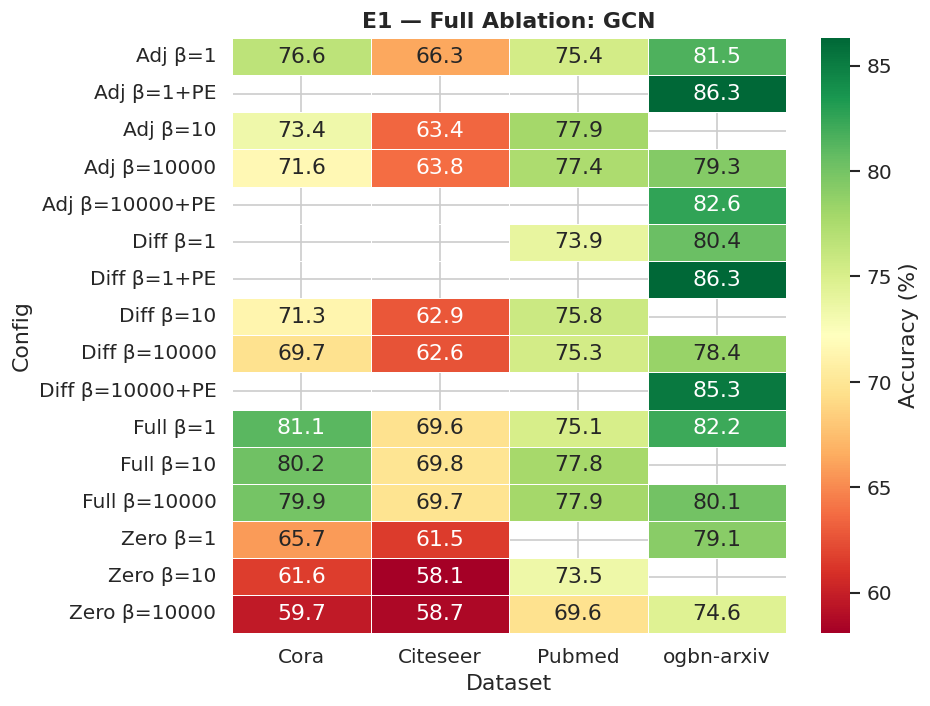

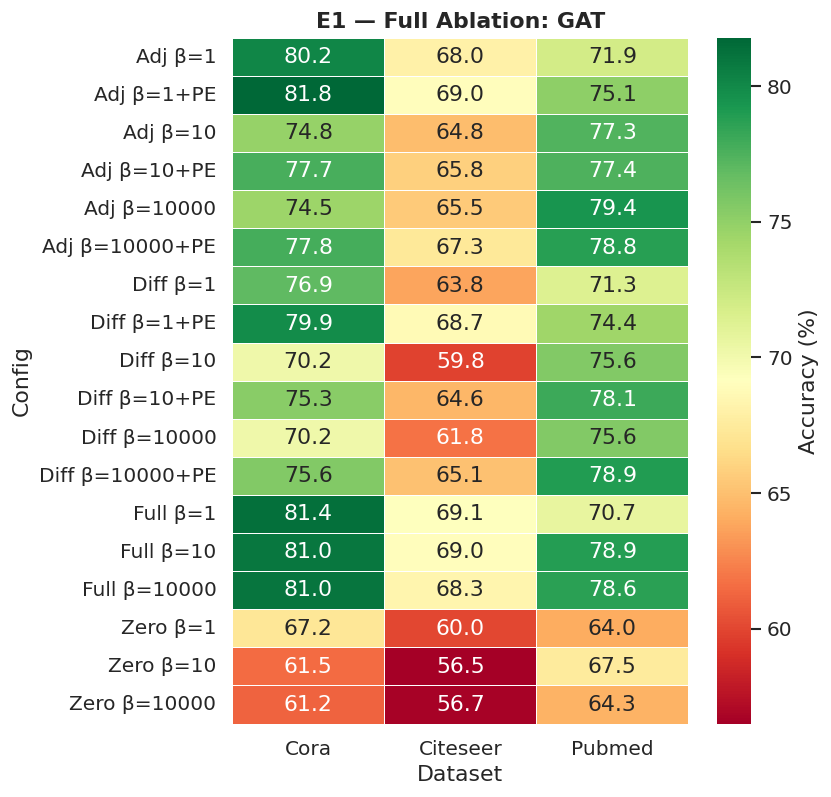

In [74]:
# ── E1: Render full ablation heatmap ─────────────────────────────────────────
for model in ['GCN','GAT']:
    sub = full_ablation[full_ablation['model']==model].copy()
    if sub.empty: continue
    sub['config'] = (
        sub['propagation'].map(PROP_LABELS).fillna(sub['propagation'])
        + ' β=' + sub['beta'].astype(int).astype(str)
        + sub.get('use_pe', pd.Series(False, index=sub.index)).map({True:'+PE', False:''})
    )
    pivot = sub.pivot_table(index='config', columns='dataset', values='acc_pct')
    avail_ds = [d for d in DATASET_ORDER if d in pivot.columns]
    pivot = pivot[avail_ds]

    fig, ax = plt.subplots(figsize=(max(7, len(avail_ds)*2), max(6, len(pivot)*0.38)))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=.4,
                ax=ax, cbar_kws={'label':'Accuracy (%)'})
    ax.set_title(f'E1 — Full Ablation: {model}', fontweight='bold')
    ax.set_xlabel('Dataset'); ax.set_ylabel('Config')
    plt.tight_layout()
    plt.show()

## E2 · Appendix: Convergence Stats Table
🟡 **Partial** — Feeds from D6.

In [75]:
# ── E2: Use conv_df computed in D6 ───────────────────────────────────────────
print('E2 Convergence Statistics Table (from D6):')
try:
    display(conv_df)
except NameError:
    print('Run D6 cells first to populate conv_df.')

E2 Convergence Statistics Table (from D6):


,Source,Propagation,Beta,Iters to ε=1e-6,Final Residual,Status
0,Cora IID,adjacency,1,>max,0.015248,done
1,Cora IID,adjacency,10,>max,0.019180,done
2,Cora IID,adjacency,10000,>max,0.019963,done
3,Cora IID,diffusion,1,>max,0.765105,done
4,Cora IID,diffusion,10,>max,0.826496,done
5,Cora IID,diffusion,10000,>max,0.844048,done
6,Cora PE,adjacency,1,>max,0.015248,done
7,Cora PE,adjacency,10,>max,0.019180,done
8,Cora PE,adjacency,10000,>max,0.019979,done
9,Cora PE,diffusion,1,>max,0.765105,done


## E3 · Appendix: Propagation Cost vs GNN Training Cost
🟡 **Partial** — Cora <1% stated; verify and extend to OGBN-Arxiv.

In [76]:
# ── E3: Extract runtime from propagation_stats JSONs ─────────────────────────
e3_rows = []
for label, d in D6_STATS_DIRS.items():
    d = Path(d)
    if not d.exists(): continue
    for f in sorted(d.glob('*.json'))[:3]:   # sample first 3 per dir
        with open(f) as fh: meta = json.load(fh)
        e3_rows.append({
            'Source'         : label,
            'Propagation'    : meta.get('propagation_mode',''),
            'Beta'           : meta.get('beta'),
            'Prop Runtime(s)': round(meta.get('runtime',0), 4),
            'GNN Train(s)'   : None,   # fill from training CSV timestamps
            'Prop % of Total': None,
        })

if e3_rows:
    e3_df = pd.DataFrame(e3_rows)
    print('E3 Propagation Cost:')
    display(e3_df)
else:
    print('No propagation_stats JSONs found. Run D6 with --track_convergence first.')

E3 Propagation Cost:


,Source,Propagation,Beta,Prop Runtime(s),GNN Train(s),Prop % of Total
0,Cora IID,adjacency,10000,0,None,None
1,Cora IID,adjacency,10000,0,None,None
2,Cora IID,adjacency,10000,0,None,None
3,Cora PE,adjacency,10000,0,None,None
4,Cora PE,adjacency,10000,0,None,None
5,Cora PE,adjacency,10000,0,None,None
6,Citeseer,adjacency,10000,0,None,None
7,Citeseer,adjacency,10000,0,None,None
8,Citeseer,adjacency,10000,0,None,None
9,Pubmed,adjacency,10000,0,None,None


## E4 · Appendix: Dataset Statistics Table
🟡 **Extend** — Current Table 7 covers Cora/Citeseer/Pubmed. Add 5 more datasets.

In [77]:
# ── E4: Dataset statistics (extend with Amazon + Texas + Wisconsin + OGBN) ───
E4_TABLE = pd.DataFrame([
    {'Dataset':'Cora',         '#Nodes':2708,   '#Edges':10556,   '#Classes':7,  'Features':1433, 'h':0.81, 'Avg missing neigh K=10 β=10':None},
    {'Dataset':'Citeseer',     '#Nodes':3327,   '#Edges':9228,    '#Classes':6,  'Features':3703, 'h':0.74, 'Avg missing neigh K=10 β=10':None},
    {'Dataset':'Pubmed',       '#Nodes':19717,  '#Edges':88648,   '#Classes':3,  'Features':500,  'h':0.80, 'Avg missing neigh K=10 β=10':None},
    {'Dataset':'OGBN-Arxiv',   '#Nodes':169343, '#Edges':1166243, '#Classes':40, 'Features':128,  'h':0.66, 'Avg missing neigh K=10 β=10':None},
    {'Dataset':'Amazon-Comp',  '#Nodes':13752,  '#Edges':574418,  '#Classes':10, 'Features':767,  'h':0.78, 'Avg missing neigh K=10 β=10':None},
    {'Dataset':'Amazon-Photos','#Nodes':7650,   '#Edges':238162,  '#Classes':8,  'Features':745,  'h':0.83, 'Avg missing neigh K=10 β=10':None},
    {'Dataset':'Texas',        '#Nodes':183,    '#Edges':325,     '#Classes':5,  'Features':1703, 'h':0.11, 'Avg missing neigh K=10 β=10':None},
    {'Dataset':'Wisconsin',    '#Nodes':251,    '#Edges':515,     '#Classes':5,  'Features':1703, 'h':0.20, 'Avg missing neigh K=10 β=10':None},
])

# Fill avg missing neighbor fraction from propagation_stats where available
for label, d in D6_STATS_DIRS.items():
    d = Path(d)
    if not d.exists(): continue
    for f in sorted(d.glob('*.json'))[:1]:
        with open(f) as fh: meta = json.load(fh)
        for client in meta.get('clients', []):
            total = client.get('nodes_total',0)
            unknown = client.get('nodes_unknown',0)
            if total > 0:
                frac = round(unknown/total, 3)
                ds_name = label.split()[0]
                mask = E4_TABLE['Dataset'].str.startswith(ds_name)
                if mask.any():
                    E4_TABLE.loc[mask, 'Avg missing neigh K=10 β=10'] = frac
                break

print('E4 Dataset Statistics Table:')
display(E4_TABLE)

E4 Dataset Statistics Table:


,Dataset,#Nodes,#Edges,#Classes,Features,h,Avg missing neigh K=10 β=10
0,Cora,2708,10556,7,1433,0.81,0.708
1,Citeseer,3327,9228,6,3703,0.74,0.666
2,Pubmed,19717,88648,3,500,0.80,0.717
3,OGBN-Arxiv,169343,1166243,40,128,0.66,0.89
4,Amazon-Comp,13752,574418,10,767,0.78,None
5,Amazon-Photos,7650,238162,8,745,0.83,None
6,Texas,183,325,5,1703,0.11,None
7,Wisconsin,251,515,5,1703,0.20,None


## E5 · Appendix: FedCog Comparison Detail
🔴 **New** — Literature check only; no experimental run needed if published numbers exist.

In [78]:
# ── E5: FedCog comparison ─────────────────────────────────────────────────────
# FedCog (Zheng et al.) — check if Cora/Citeseer numbers are published
# If available, enter them here. If not, use qualitative comparison.

E5_TABLE = pd.DataFrame([
    {'Method':'FedProp (Ours)','Cora':'see B1','Citeseer':'see B1','Notes':'Our method'},
    {'Method':'FedCog',       'Cora':None,     'Citeseer':None,    'Notes':'TODO: check Zheng et al. paper'},
])

print('E5 FedCog Comparison (fill from literature):')
display(E5_TABLE)
print()
print('Action: search for FedCog paper (Zheng et al.) and check if they report Cora/Citeseer accuracy')
print('        under a comparable protocol (K=10 clients, same β values).')

E5 FedCog Comparison (fill from literature):


,Method,Cora,Citeseer,Notes
0,FedProp (Ours),see B1,see B1,Our method
1,FedCog,NaN,NaN,TODO: check Zheng et al. paper



Action: search for FedCog paper (Zheng et al.) and check if they report Cora/Citeseer accuracy
        under a comparable protocol (K=10 clients, same β values).


---
## Catalog Status Tracker

In [79]:
# ── Live status summary (update 'actual_status' as runs complete) ─────────────
STATUS_TRACKER = pd.DataFrame([
    # id,  type,   title,                               catalog_status,   actual_status
    ('B1', 'Table','Main Accuracy (6 datasets)',         'Partial',        None),
    ('B2', 'Table','Comm Efficiency (all datasets)',     'Extend',         None),
    ('B3', 'Table','Backbone Comparison',                'Restructure',    'Done'),
    ('B4', 'Table','Heterophilic Results',               'To Run',         None),
    ('C1', 'Fig',  'Comm-Efficiency Scatter',            'Extend',         None),
    ('C2', 'Fig',  'Error Decomposition',                'New',            None),
    ('C3', 'Fig',  'Convergence Grid',                   'Extend',         None),
    ('C4', 'Fig',  'Accuracy vs K',                      'Extend',         None),
    ('C5', 'Fig',  'Recovery vs Homophily',              'New',            None),
    ('C6', 'Fig',  'PE Impact',                          'Extend',         None),
    ('D1', 'Data', 'Amazon Computers',                   'Done (write-up)',None),
    ('D2', 'Data', 'Amazon Photos',                      'Done (write-up)',None),
    ('D3', 'Data', 'Texas GCN',                          'To Run',         None),
    ('D4', 'Data', 'Wisconsin GCN',                      'To Run',         None),
    ('D5', 'Data', 'FedSage+ baseline',                  'To Run',         None),
    ('D6', 'Data', 'Convergence tracking',               'Partial',        None),
    ('D7', 'Data', 'OGBN scalability K=1..20',           'To Run',         None),
    ('D8', 'Data', 'PE on Pubmed+OGBN',                  'To Run',         None),
    ('D9', 'Data', 'Comm cost metric all 6',             'Partial',        None),
    ('E1', 'App',  'Full ablation all datasets',         'Extend',         None),
    ('E2', 'App',  'Convergence stats table',            'Partial',        None),
    ('E3', 'App',  'Prop cost vs GNN train cost',        'Partial',        None),
    ('E4', 'App',  'Dataset statistics table',           'Extend',         None),
    ('E5', 'App',  'FedCog comparison',                  'New',            None),
], columns=['ID','Type','Title','Catalog Status','Actual Status'])

STATUS_TRACKER['Actual Status'] = STATUS_TRACKER['Actual Status'].fillna(STATUS_TRACKER['Catalog Status'])

ICON = {'Done':'🟢','Done (write-up)':'🟡','Partial':'🟡','Extend':'🟡',
        'Restructure':'🟢','New':'🔴','To Run':'🔴'}
STATUS_TRACKER['Icon'] = STATUS_TRACKER['Actual Status'].map(ICON).fillna('⚪')

counts = STATUS_TRACKER['Actual Status'].value_counts()
print('=== Catalog Completion Status ===')
for status, cnt in counts.items():
    print(f'  {ICON.get(status,"⚪")} {status}: {cnt} items')
print(f'  Total: {len(STATUS_TRACKER)}')

display(STATUS_TRACKER[['Icon','ID','Type','Title','Actual Status']])

=== Catalog Completion Status ===
  🟡 Extend: 7 items
  🔴 To Run: 6 items
  🟡 Partial: 5 items
  🔴 New: 3 items
  🟡 Done (write-up): 2 items
  🟢 Done: 1 items
  Total: 24


,Icon,ID,Type,Title,Actual Status
0,🟡,B1,Table,Main Accuracy (6 datasets),Partial
1,🟡,B2,Table,Comm Efficiency (all datasets),Extend
2,🟢,B3,Table,Backbone Comparison,Done
3,🔴,B4,Table,Heterophilic Results,To Run
4,🟡,C1,Fig,Comm-Efficiency Scatter,Extend
5,🔴,C2,Fig,Error Decomposition,New
6,🟡,C3,Fig,Convergence Grid,Extend
7,🟡,C4,Fig,Accuracy vs K,Extend
8,🔴,C5,Fig,Recovery vs Homophily,New
9,🟡,C6,Fig,PE Impact,Extend
